In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

- 공공데이터 포털에 있는 데이터를 Pandas의 melt, concat, transpose와 같은 reshape 기능을 활용해 분석
- groupby, pivot_table, info, describe, value_counts등을 통한 데이터 요약과 분석
- 이를 통해 전혀 다른 두 데이터의 정제와 병합, 수치형 데이터의 차이를 이해하고 다양한 그래프로 시각화(barplot, lineplot, scatterplot, lmplot, swarmplot, histplot)

# 1. 패키지로드 & 한글설정 & 경고메세지 ignore

In [4]:
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 시각화의 선명도를 높임
%config InlineBackend.figure_format = "retina"

# 한글설정
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

# 다른 폰트를 기본으로 하려면
import matplotlib.font_manager as fm
font_file = 'C:\Windows\Fonts\BAUHS93.TTF'
font_name = fm.FontProperties(fname=font_file).get_name()
# warning(경고) 안보이게
import warnings
# warnings.filterwarnings(action='ignore')  # 경고 메세지 무시
warnings.filterwarnings(action='default') 

<>:16: DeprecationWarning: invalid escape sequence '\W'
<>:16: DeprecationWarning: invalid escape sequence '\W'
C:\Users\Admin\AppData\Local\Temp\ipykernel_2992\2491295481.py:16: DeprecationWarning: invalid escape sequence '\W'
  font_file = 'C:\Windows\Fonts\BAUHS93.TTF'


# 2. 데이터 다운로드
- https://www.data.go.kr 에서 "아파트 분양 가격"을 검색한 csv 다운로드

## (1) 2013년9월부터 2015년8월까지 데이터는 df_first 변수에 담아 탐색

In [5]:
%ls "C:\Ai_x\download\부동산\"

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: 3664-591E

 C:\Ai_x\download\부동산 디렉터리

2025-05-08  오후 12:19    <DIR>          .
2025-05-08  오후 12:19    <DIR>          ..
2021-01-02  오후 03:44             2,163 전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv
2025-04-30  오후 02:04           419,340 주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20241231.csv
2025-05-08  오후 12:19            47,200 최종전국평당분양가격(결측치제외).csv
               3개 파일             468,703 바이트
               2개 디렉터리  159,622,275,072 바이트 남음


sys:1: ResourceWarning: unclosed socket <zmq.Socket(zmq.PUSH) at 0x2e9b7771540>
C:\Users\Admin\anaconda3\lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedWriter name=5>
  return process_handler(cmd, _system_body)
C:\Users\Admin\anaconda3\lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  return process_handler(cmd, _system_body)
C:\Users\Admin\anaconda3\lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedReader name=7>
  return process_handler(cmd, _system_body)


In [6]:
df_first = pd.read_csv('C:\Ai_x\download\부동산\전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',
                      encoding='cp949')
df_first.sample()


<>:1: DeprecationWarning: invalid escape sequence '\A'
<>:1: DeprecationWarning: invalid escape sequence '\A'
C:\Users\Admin\AppData\Local\Temp\ipykernel_2992\794481952.py:1: DeprecationWarning: invalid escape sequence '\A'
  df_first = pd.read_csv('C:\Ai_x\download\부동산\전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',


,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
7,경기,10855,10855,10791,10784,10876,10646,10266,10124,10134,...,10356,10379,10391,10355,10469,10684,10685,10573,10518,10573


In [7]:
# set_index('열이름') : 열을 index로 setting
# reset_index() : index를 열로 setting
df_first.set_index('지역', inplace=True)

In [8]:
# isna(), isnull() : 결측치 여부
# notna(), no
df_first.isna().sum()

2013년12월    0
2014년1월     0
2014년2월     0
2014년3월     0
2014년4월     0
2014년5월     0
2014년6월     0
2014년7월     0
2014년8월     0
2014년9월     0
2014년10월    0
2014년11월    0
2014년12월    0
2015년1월     0
2015년2월     0
2015년3월     0
2015년4월     0
2015년5월     0
2015년6월     0
2015년7월     0
2015년8월     0
dtype: int64

- color map 참조 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

<Axes: ylabel='지역'>

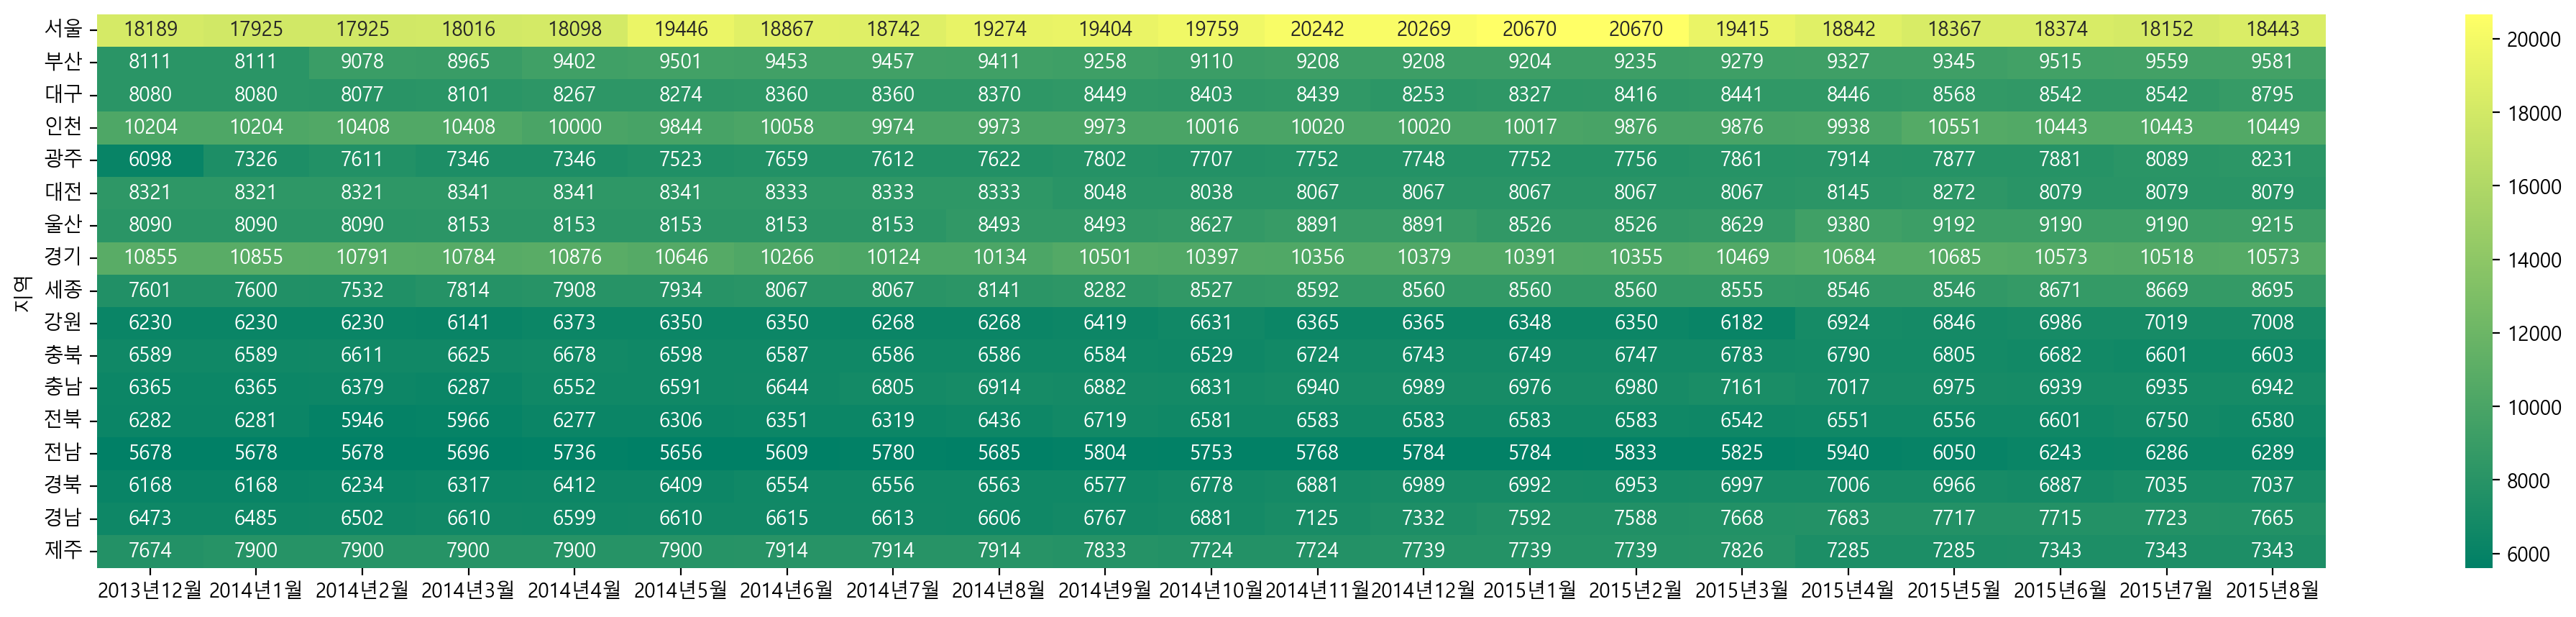

In [9]:
df_first.head()
plt.figure(figsize=(25,5))
sns.heatmap(df_first, annot=True, fmt='d', cmap='summer')

<>:2: DeprecationWarning: invalid escape sequence '\A'
<>:2: DeprecationWarning: invalid escape sequence '\A'
C:\Users\Admin\AppData\Local\Temp\ipykernel_2992\3644735423.py:2: DeprecationWarning: invalid escape sequence '\A'
  df_first = pd.read_csv('C:\Ai_x\download\부동산\전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',


<Axes: ylabel='지역'>

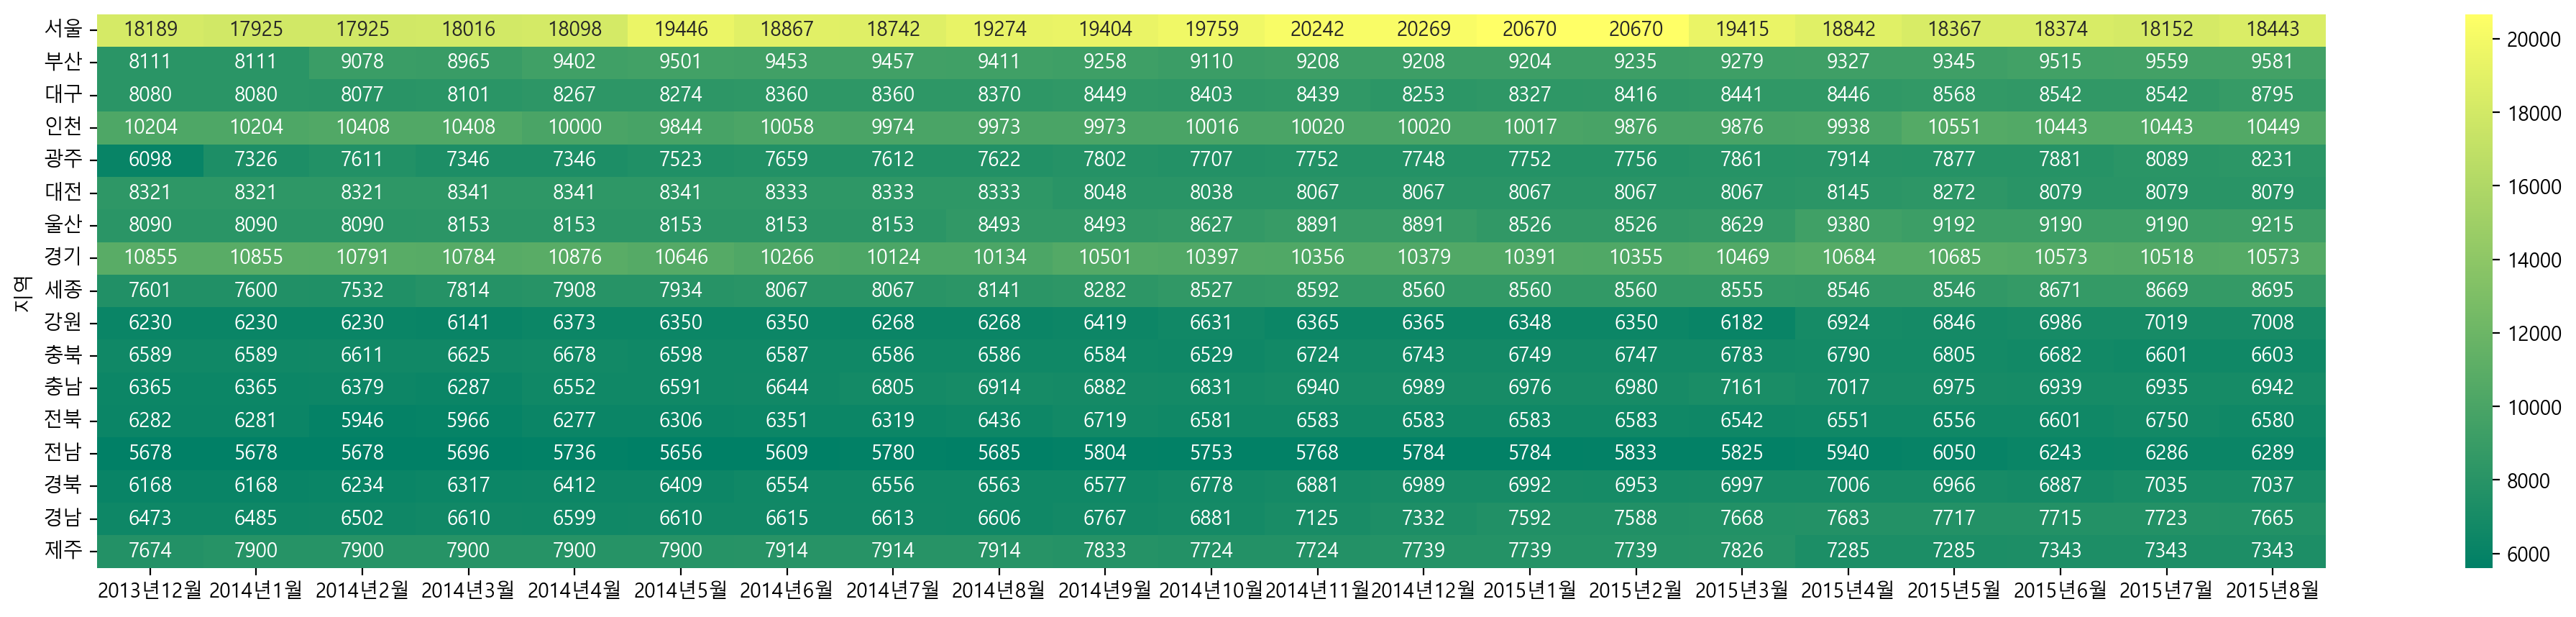

In [10]:
# 문제1번 
df_first = pd.read_csv('C:\Ai_x\download\부동산\전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',
                      encoding='cp949')
df_first.sample()
df_first.set_index('지역', inplace=True)
df_first.head()
plt.figure(figsize=(25,5))
sns.heatmap(df_first, annot=True, fmt='d', cmap='summer')

## (2) 2015이후 데이터 분양가격에 간헐적으로 comma(,) 추가하여 csv로 출력
- 분양가격에 np.nan, '',8,111c

In [15]:
ex = pd.read_csv('C:\Ai_x\download\부동산\주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20241231.csv',
                encoding='cp949')
ex.head()

<>:1: DeprecationWarning: invalid escape sequence '\A'
<>:1: DeprecationWarning: invalid escape sequence '\A'
C:\Users\Admin\AppData\Local\Temp\ipykernel_2992\2410657064.py:1: DeprecationWarning: invalid escape sequence '\A'
  ex = pd.read_csv('C:\Ai_x\download\부동산\주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20241231.csv',


,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,5841
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879


In [16]:
# isna(), isnull() - 결측치 여부
# notnull(), notna() - 결측치가 아닌지 여부
print('전체 갯수:', ex.shape[0])
print('결측치 아닌 갯수:', ex['분양가격(제곱미터)'].notna().sum())
print('결측치 갯수:', ex['분양가격(제곱미터)'].isna().sum())

전체 갯수: 9095
결측치 아닌 갯수: 8481
결측치 갯수: 614


In [17]:
# 분양가격(제곱미터)가 결측치인 행 상위2개
ex[ex['분양가격(제곱미터)'].isnull()].head(2)


,지역명,규모구분,연도,월,분양가격(제곱미터)
368,광주,전용면적 85제곱미터초과 102제곱미터이하,2016,2,NaN
369,광주,전용면적 102제곱미터초과,2016,2,NaN


In [18]:
# 분양가격(제곱미터) 컬럼의 type을 float64로 타입 변환 : astype(), pd.to_numeric()
type(ex.loc[368, '분양가격(제곱미터)']),type(ex.loc[0,'분양가격(제곱미터)'])
pd.to_numeric(ex['분양가격(제곱미터)'],errors='coerce').isna().sum() # 에러나는 행은 열측치로

740

In [19]:
# 분양가격(제곱미터) 컬럼이 space인 행
ex[ex['분양가격(제곱미터)'].str.strip() == ''].head(1)

,지역명,규모구분,연도,월,분양가격(제곱미터)
28,광주,전용면적 85제곱미터초과 102제곱미터이하,2015,10,


In [20]:
nanex=ex.loc[368] # 분양가격이 결측치
spaceex = ex.loc[28] # 분양가격이 space
ex.loc[0] # 분양가격이 정상

지역명             서울
규모구분          모든면적
연도            2015
월               10
분양가격(제곱미터)    5841
Name: 0, dtype: object

In [21]:
# 분양가격이 nan이거나 space면 0, 그외 분양가격의 문자자리수를 return하는 함수
def get_pricelen(row):
    price = row['분양가격(제곱미터)']
    # np.isnan(스칼라값) : 스칼라변수가 결측치인지
    # pd.isna(스칼라변수) : 스칼라변수가 결측치(np.nan, None)인지 여부
    # pd.notnull(스칼라변수) : 결측치가 아닌지 여부
    # 1차원이나2차원변수.isna() : 결측치 여부
    if pd.notnull(price) and price.strip()!='':
        return len(price)
    else:
        return 0
get_pricelen(nanex), get_pricelen(spaceex), get_pricelen(ex.loc[0])


(0, 0, 4)

In [22]:
ex['자리수'] = ex.apply(get_pricelen, axis=1)
ex.자리수.unique()

array([4, 0, 5], dtype=int64)

In [23]:
ex.index.name = 'idx'  #인덱스 열 삽입
ex.head(2)


,지역명,규모구분,연도,월,분양가격(제곱미터),자리수
idx,,,,,,
0,서울,모든면적,2015,10,5841,4
1,서울,전용면적 60제곱미터이하,2015,10,5652,4


In [24]:
ex = ex.reset_index()

In [25]:
# 자리수가 5 이면서 idx 가 5의 배수
ex[(ex.자리수 == 5) & (ex.idx%5==0)].head(1)

,idx,지역명,규모구분,연도,월,분양가격(제곱미터),자리수
8245,8245,서울,모든면적,2023,11,10347,5


In [26]:
# 컴마추가안 함 : nanex, space.ex, ex.loc[1]
# 컴마추가 : ex.loc[0], ex.loc[8245]

In [27]:
nanex=ex.loc[368] # 분양가격이 결측치
spaceex = ex.loc[28] # 분양가격이 space


In [28]:
# 2022년 데이터 흉내내기 위한 함수  : nan, ' ', '  ', '5123', '5,123'
def comma_append(row):
    price = row['분양가격(제곱미터)']
    if (row.idx%5==0) & (row.자리수>=4):
        price = price[:-3] + ',' + price[-3:]
    return price

comma_append(nanex), comma_append(spaceex), comma_append(ex.loc[1]),\
comma_append(ex.loc[0]), comma_append(ex.loc[8245])

(nan, '  ', '5652', '5,841', '10,347')

In [29]:
ex['분양가격(제곱미터)'] = ex.apply(comma_append, axis=1)

In [30]:
ex.drop(['idx','자리수'], axis = 1, inplace = True)  # 또는 coloumns

In [31]:
ex.head()

,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,"5,841"
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879


In [65]:
# 문제2번
ex.to_csv('data/전국제곱미터당분양가격(2015년10월부터).csv', index=False)
df_last = pd.read_csv('data/전국제곱미터당분양가격(2015년10월부터).csv')
def commadrop(row):
    pd.options.mode.copy_on_write = True
    price = row['분양가격(제곱미터)']
    if pd.isna(price):   # np.nan 이거나 none 인지 여부
        row['분양가격(제곱미터)'] = np.nan
    elif price.strip() == '': # space 이면 np.nan로
        row['분양가격(제곱미터)'] = np.nan
    elif price.find(',')!=-1: # 콤마가 있으면 콤마 없애기
        row['제곱미터분양가격'] = ''.join(price.split(','))
    else:
        row['제곱미터분양가격'] = price
    return row
commadrop(df_last.loc[0]) # 콤마 제외
commadrop(df_last.loc[1]) # 그대로
commadrop(df_last.loc[28]) # 공백문자의 경우 nan
commadrop(df_last.loc[368]) # nan의 경우 nan

df_last = df_last.apply(commadrop, axis=1)
df_last.head(2)

df_last['제곱미터분양가격'] = df_last['제곱미터분양가격'].astype(np.float64)

df_last.drop(['제곱미터분양가격'], axis=1, inplace=True)

def commadrop2(price):
    if pd.isna(price):
        return np.nan
    elif price.strip() == '':
        return np.nan
    elif price.find(',') != -1:
        return int(price.replace(',',''))
    else:
        return int(price)
commadrop2(df_last.loc[0, '분양가격(제곱미터)']) # 콤마제외한 문자를 숫자로 
commadrop2(df_last.loc[1, '분양가격(제곱미터)']) # 콤마없는 문자를 숫자로 
commadrop2(df_last.loc[28, '분양가격(제곱미터)']) # 공백문자를 nan
commadrop2(df_last.loc[368, '분양가격(제곱미터)']) # nan을 nan

df_last['제곱미터당분양가격']  = df_last['분양가격(제곱미터)'].map(commadrop2)

df_last['평당분양가격']=df_last['제곱미터당분양가격']*3.3

df_last.drop(['제곱미터당분양가격'], axis=1, inplace=True)


df_last.drop(['규모구분'], axis=1, inplace=True)

df_last = df_last[['지역명', '분양가격(제곱미터)', '연도', '월', '평당분양가격']]



df_last

,지역명,분양가격(제곱미터),연도,월,평당분양가격
0,서울,"5,841",2015,10,19275.3
1,서울,5652,2015,10,18651.6
2,서울,5882,2015,10,19410.6
3,서울,5721,2015,10,18879.3
4,서울,5879,2015,10,19400.7
...,...,...,...,...,...
9090,제주,"7,703",2024,8,25419.9
9091,제주,NaN,2024,8,NaN
9092,제주,7515,2024,8,24799.5
9093,제주,NaN,2024,8,NaN


In [33]:
# 간헐적으로 평당분양가에 ,가 있거나 np.nan이 있거나 space가 있는 데이터 csv로 백업
ex.to_csv('data/전국제곱미터당분양가격(2015년10월부터).csv', index=False)
ex.head()

,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,"5,841"
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879


## (3) 이후 데이터는 df_last 변수에 담아 탐색

In [34]:
df_last = pd.read_csv('data/전국제곱미터당분양가격(2015년10월부터).csv')
display(df_last.shape)

(9095, 5)

In [35]:
# 데이터 요약하기
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9095 entries, 0 to 9094
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   지역명         9095 non-null   object
 1   규모구분        9095 non-null   object
 2   연도          9095 non-null   int64 
 3   월           9095 non-null   int64 
 4   분양가격(제곱미터)  8481 non-null   object
dtypes: int64(2), object(3)
memory usage: 355.4+ KB


# 3. df_last의 데이터 결측치를 확인하고 대체 고민

In [36]:
# 열별 결측치 갯수
df_last.isna().sum()

지역명             0
규모구분            0
연도              0
월               0
분양가격(제곱미터)    614
dtype: int64

In [37]:
# 열별 결측치를 제외한 갯수
df_last.notna().sum()

지역명           9095
규모구분          9095
연도            9095
월             9095
분양가격(제곱미터)    8481
dtype: int64

# 4. df_last 데이셋에 평당분양가격컬럼 추가

## (1) astype('float')나 pd.to_numeric() 사용
## (2) 6,222 => 6222 수정, space가 저장된 경우 nan으로 수정하는 함수를 apply나 map적용
## (3) df_last['분양가격(제곱미터)']*3.3

In [38]:
# df_last['분양가격(제곱미터)'].astype(np.float64)*3.3   에러 발생
# df_last['분양가격(제곱미터)'].str.replace(',','').astype(np.float64)
# , 와 space 때문에 에러

In [39]:
df_last

,지역명,규모구분,연도,월,분양가격(제곱미터)
0,서울,모든면적,2015,10,"5,841"
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879
...,...,...,...,...,...
9090,제주,모든면적,2024,8,"7,703"
9091,제주,전용면적 60제곱미터이하,2024,8,NaN
9092,제주,전용면적 60제곱미터초과 85제곱미터이하,2024,8,7515
9093,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,8,NaN


### apply

In [40]:
# 콤마가 있는 문자에서 콤마 없애기 방법1
temp = '12,523'
temp.replace(',','')

'12523'

In [41]:
# 콤마가 있는 문자에서 콤마 없애기 방법2
temp = '12,523'
tempsplited = temp.split(',')
print(tempsplited)
print(''.join(tempsplited))

['12', '523']
12523


In [42]:
# 분양가격 컬럼에 콤마(,)가 있는 경우 콤마(,)를 제거('5,123' -> '5123')
# 공백문자가 있는 경우 np.nan로 바꾸는 함수
def commadrop(row):
    pd.options.mode.copy_on_write = True
    price = row['분양가격(제곱미터)']
    if pd.isna(price):   # np.nan 이거나 none 인지 여부
        row['분양가격(제곱미터)'] = np.nan
    elif price.strip() == '': # space 이면 np.nan로
        row['분양가격(제곱미터)'] = np.nan
    elif price.find(',')!=-1: # 콤마가 있으면 콤마 없애기
        row['제곱미터분양가격'] = ''.join(price.split(','))
    else:
        row['제곱미터분양가격'] = price
    return row
commadrop(df_last.loc[0]) # 콤마 제외
commadrop(df_last.loc[1]) # 그대로
commadrop(df_last.loc[28]) # 공백문자의 경우 nan
commadrop(df_last.loc[368]) # nan의 경우 nan


지역명                                광주
규모구분          전용면적 85제곱미터초과 102제곱미터이하
연도                               2016
월                                   2
분양가격(제곱미터)                        NaN
Name: 368, dtype: object

In [43]:
%%time
# 공백문자는 결측치로, 콤마는 제거하기를 모든 행에 적용

df_last = df_last.apply(commadrop, axis=1)
df_last.head(2)

CPU times: total: 9.42 s
Wall time: 10.1 s


,규모구분,분양가격(제곱미터),연도,월,제곱미터분양가격,지역명
0,모든면적,"5,841",2015,10,5841,서울
1,전용면적 60제곱미터이하,5652,2015,10,5652,서울


In [44]:
df_last['제곱미터분양가격'] = df_last['제곱미터분양가격'].astype(np.float64)

In [45]:
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9095 entries, 0 to 9094
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   규모구분        9095 non-null   object 
 1   분양가격(제곱미터)  8355 non-null   object 
 2   연도          9095 non-null   int64  
 3   월           9095 non-null   int64  
 4   제곱미터분양가격    8355 non-null   float64
 5   지역명         9095 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 426.5+ KB


### map

In [46]:
df_last.drop(['제곱미터분양가격'], axis=1, inplace=True)
df_last.sample(1)

,규모구분,분양가격(제곱미터),연도,월,지역명
3349,전용면적 102제곱미터초과,4877,2019,1,대전


In [47]:
# 결측치->결측치 return, 공백문자->결측치 return, '3,198' -> 3198 return, '3198'->3198 return,  
def commadrop2(price):
    if pd.isna(price):
        return np.nan
    elif price.strip() == '':
        return np.nan
    elif price.find(',') != -1:
        return int(price.replace(',',''))
    else:
        return int(price)
commadrop2(df_last.loc[0, '분양가격(제곱미터)']) # 콤마제외한 문자를 숫자로 
commadrop2(df_last.loc[1, '분양가격(제곱미터)']) # 콤마없는 문자를 숫자로 
commadrop2(df_last.loc[28, '분양가격(제곱미터)']) # 공백문자를 nan
commadrop2(df_last.loc[368, '분양가격(제곱미터)']) # nan을 nan

nan

- apply(함수, axis) : 1차원, 2차원(axis 지정. axis기본값0)
- map(함수) : 1차원
- applymap(함수) : 2차원(모든 요소들에 함수를 적용)

In [48]:
#df_last['분양가격(제곱미터)'].apply(commadrop2)
df_last['제곱미터당분양가격']  = df_last['분양가격(제곱미터)'].map(commadrop2)
df_last.tail()

,규모구분,분양가격(제곱미터),연도,월,지역명,제곱미터당분양가격
9090,모든면적,"7,703",2024,8,제주,7703.0
9091,전용면적 60제곱미터이하,NaN,2024,8,제주,NaN
9092,전용면적 60제곱미터초과 85제곱미터이하,7515,2024,8,제주,7515.0
9093,전용면적 85제곱미터초과 102제곱미터이하,NaN,2024,8,제주,NaN
9094,전용면적 102제곱미터초과,7950,2024,8,제주,7950.0


In [49]:
df_last['평당분양가격']=df_last['제곱미터당분양가격']*3.3
df_last.head(1)

,규모구분,분양가격(제곱미터),연도,월,지역명,제곱미터당분양가격,평당분양가격
0,모든면적,"5,841",2015,10,서울,5841.0,19275.3


# 5. df_last 데이터셋에서 전용면적 컬럼을 추가한다
- 전용면적 컬럼, 필요없는 컬럼 처리로 메모리 절약

In [240]:
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9095 entries, 0 to 9094
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   규모구분        9095 non-null   object 
 1   분양가격(제곱미터)  8355 non-null   object 
 2   연도          9095 non-null   int64  
 3   월           9095 non-null   int64  
 4   지역명         9095 non-null   object 
 5   제곱미터당분양가격   8355 non-null   float64
 6   평당분양가격      8355 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 497.5+ KB


In [246]:
# 규모부분 칼럼을 중복단어를 제외하고 전용면적 칼럼으로
df_last['전용면적'] = df_last['규모구분'].str.replace('전용면적','').str.replace('제곱미터','㎡')\
                      .str.replace('제곱미터','㎡').str.replace('초과','~').str.replace('이하','').str.replace(' ','')


In [248]:
print(df_last['규모구분'].unique())
print(df_last['전용면적'].unique())

['모든면적' '전용면적 60제곱미터이하' '전용면적 60제곱미터초과 85제곱미터이하' '전용면적 85제곱미터초과 102제곱미터이하'
 '전용면적 102제곱미터초과']
['모든면적' '60㎡' '60㎡~85㎡' '85㎡~102㎡' '102㎡~']


# 6. 메모리 사용량을 줄이기 위해 불필요한 컬럼 제거

In [249]:
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9095 entries, 0 to 9094
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   규모구분        9095 non-null   object 
 1   분양가격(제곱미터)  8355 non-null   object 
 2   연도          9095 non-null   int64  
 3   월           9095 non-null   int64  
 4   지역명         9095 non-null   object 
 5   제곱미터당분양가격   8355 non-null   float64
 6   평당분양가격      8355 non-null   float64
 7   전용면적        9095 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 568.6+ KB


In [251]:
df_last.drop(['규모구분','분양가격(제곱미터)','제곱미터당분양가격'], 
             axis=1,inplace=True)

In [252]:
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9095 entries, 0 to 9094
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연도      9095 non-null   int64  
 1   월       9095 non-null   int64  
 2   지역명     9095 non-null   object 
 3   평당분양가격  8355 non-null   float64
 4   전용면적    9095 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 355.4+ KB


In [253]:
df_last.to_csv('data/df_last.csv', index=False) # 전처리 단계 백업

# 7. 데이터 집계
- GroupBy(unstack()함수 이용) vs. pivot_table()
- GroupBy가 조금 시간이 적게 걸릴 수 있음
- 우선 결측치 대체전 데이터 집계와 시각화를 할 예정

- df_last.groupby(["인덱스로사용할컬럼명"])["계산할컬럼명"].연산함수()
- df_last.pivot_table(index=["인덱스로사용할컬럼명"],
                    values=["계산할컬럼명"],
                    aggfunc="연산함수명")
- pd.pivot_table(df_last, index=["인덱스로사용할컬럼명"],
                    values=["계산할컬럼명"],
                    aggfunc="연산함수명")

## (1) 지역별 데이터수

In [254]:
# 지역명별 데이터 행수(결측치 포함)을 정렬하여 출력
df_last['지역명'].value_counts()

서울    535
강원    535
경남    535
경북    535
전남    535
전북    535
충남    535
충북    535
세종    535
인천    535
울산    535
대전    535
광주    535
대구    535
부산    535
경기    535
제주    535
Name: 지역명, dtype: int64

In [256]:
# 지역명별 데이터 행수(결측치 제외) : 결과가 1차원 시리즈
df_last.groupby('지역명')['평당분양가격'].count().sort_values(ascending=False)

지역명
경기    535
충북    533
부산    533
인천    531
서울    527
강원    523
전북    520
경남    516
충남    516
경북    511
전남    507
대구    495
광주    450
제주    439
대전    415
세종    409
울산    395
Name: 평당분양가격, dtype: int64

In [260]:
# 지역명별 데이터 행수(결측치 제외) : 결과가 2차원 시리즈
df_last.groupby('지역명')[['평당분양가격']].count()
df_last.groupby('지역명')['평당분양가격'].count().reset_index()

,지역명,평당분양가격
0,강원,523
1,경기,535
2,경남,516
3,경북,511
4,광주,450
5,대구,495
6,대전,415
7,부산,533
8,서울,527
9,세종,409


In [262]:
# pivot_table 이용
df_last.pivot_table(index='지역명',
                   values='평당분양가격',
                   aggfunc='count').T

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
평당분양가격,523,535,516,511,450,495,415,533,527,409,395,531,507,520,439,516,533


## (2) 지역별 평당분양가격(평균, 최대값, ... 요약통계량)

In [263]:
# 지역별 평당분양가격 최대값
df_last.groupby('지역명')['평당분양가격'].max().sort_values(ascending=False).head(3)

지역명
서울    61917.9
인천    54723.9
부산    31904.4
Name: 평당분양가격, dtype: float64

In [267]:
# 지역별 평당분양가격 평균값 1차원, 2차원
df_last.groupby('지역명')['평당분양가격'].mean().sort_values(ascending=False)
df_last.groupby('지역명')[['평당분양가격']].mean().sort_values(by='평당분양가격',ascending=False)

,평당분양가격
지역명,
서울,27755.404554
제주,15912.434624
경기,15420.030280
부산,14896.949156
인천,14513.232203
대구,14434.520000
울산,13958.197975
광주,12998.216000
대전,12829.565060


In [268]:
df_last.groupby('지역명')['평당분양가격'].describe() # 2차원

,count,mean,std,min,25%,50%,75%,max
지역명,,,,,,,,
강원,523.0,10078.717400,2828.907867,6639.6,7652.700,9428.10,11873.400,17806.8
경기,535.0,15420.030280,3245.863323,10160.7,13274.250,14652.00,17168.250,24172.5
경남,516.0,10776.955814,2223.562736,7260.0,9187.200,10254.75,12031.800,16566.0
경북,511.0,10261.553425,2276.026239,6949.8,8378.700,9705.30,12500.400,15345.0
광주,450.0,12998.216000,3637.557312,7428.3,9554.325,12673.65,15213.000,24951.3
대구,495.0,14434.520000,3407.303427,8259.9,11949.300,14711.40,16338.300,30600.9
대전,415.0,12829.565060,4191.685609,8002.5,9401.700,11820.60,15310.350,30851.7
부산,533.0,14896.949156,4059.939958,9669.0,12467.400,13411.20,17301.900,31904.4
서울,527.0,27755.404554,6566.391764,16701.3,22497.750,26763.00,31054.650,61917.9


In [274]:
# 지역별 평당분양가의 최대값, 평균값, 통계요약정보를 출력(pivot_table)
df_last.pivot_table(index='지역명',
                   values='평당분양가격',
                   aggfunc='max')

df_last.pivot_table(index='지역명',
                   values='평당분양가격',
                   aggfunc='mean')

df_last.pivot_table(index='지역명',
                   values='평당분양가격',
                   aggfunc='describe').applymap(lambda x : round(x,1))

,25%,50%,75%,count,max,mean,min,std
지역명,,,,,,,,
강원,7652.7,9428.1,11873.4,523.0,17806.8,10078.7,6639.6,2828.9
경기,13274.2,14652.0,17168.2,535.0,24172.5,15420.0,10160.7,3245.9
경남,9187.2,10254.8,12031.8,516.0,16566.0,10777.0,7260.0,2223.6
경북,8378.7,9705.3,12500.4,511.0,15345.0,10261.6,6949.8,2276.0
광주,9554.3,12673.6,15213.0,450.0,24951.3,12998.2,7428.3,3637.6
대구,11949.3,14711.4,16338.3,495.0,30600.9,14434.5,8259.9,3407.3
대전,9401.7,11820.6,15310.3,415.0,30851.7,12829.6,8002.5,4191.7
부산,12467.4,13411.2,17301.9,533.0,31904.4,14896.9,9669.0,4059.9
서울,22497.8,26763.0,31054.6,527.0,61917.9,27755.4,16701.3,6566.4


## (3) 전용면적별 평당분양가격(평균)

In [287]:
%%time
df_last.groupby('전용면적')[['평당분양가격']].mean()
df_last.groupby('전용면적')[['평당분양가격']].mean().sort_values(by='평당분양가격')
df_last.pivot_table(index='전용면적',
                   values='평당분양가격',
                   aggfunc='mean')

CPU times: total: 15.6 ms
Wall time: 11.1 ms


,평당분양가격
전용면적,
102㎡~,14066.826846
60㎡,12522.774427
60㎡~85㎡,12619.048827
85㎡~102㎡,13447.672835
모든면적,12654.068098


## (4) 지역별, 전용면적별 평당분양가격(평균)

In [288]:
df_last.groupby(['지역명','전용면적'])['평당분양가격'].mean()

지역명  전용면적    
강원   102㎡~       11314.805607
     60㎡          9441.885981
     60㎡~85㎡      9383.472897
     85㎡~102㎡    10795.481053
     모든면적         9538.326168
                     ...     
충북   102㎡~        9369.532710
     60㎡          8598.227103
     60㎡~85㎡      8558.503738
     85㎡~102㎡     9418.420000
     모든면적         8547.986916
Name: 평당분양가격, Length: 85, dtype: float64

In [296]:
r = df_last.groupby(['지역명','전용면적'])['평당분양가격'].mean()
# 2차원 index 중 level0 인덱스는 그대로, level1 인덱스는 칼럼으로 올리면
r.unstack().round()


전용면적,102㎡~,60㎡,60㎡~85㎡,85㎡~102㎡,모든면적
지역명,,,,,
강원,11315.0,9442.0,9383.0,10795.0,9538.0
경기,16559.0,15291.0,14787.0,15740.0,14723.0
경남,11522.0,10122.0,10108.0,12151.0,10147.0
경북,11061.0,9732.0,9828.0,10968.0,9857.0
광주,14749.0,12254.0,12656.0,12292.0,12798.0
대구,15564.0,13748.0,14494.0,13714.0,14517.0
대전,17662.0,11834.0,11920.0,13003.0,11948.0
부산,15741.0,14449.0,14745.0,14801.0,14765.0
서울,29036.0,27371.0,26663.0,28972.0,26830.0


In [293]:
r = df_last.groupby(['지역명','전용면적'])[['평당분양가격']].mean()
r

평당분양가격
지역명 전용면적                  
강원  102㎡~     11314.805607
    60㎡        9441.885981
    60㎡~85㎡    9383.472897
    85㎡~102㎡  10795.481053
    모든면적       9538.326168
...                    ...
충북  102㎡~      9369.532710
    60㎡        8598.227103
    60㎡~85㎡    8558.503738
    85㎡~102㎡   9418.420000
    모든면적       8547.986916

[85 rows x 1 columns]

In [297]:
df_last.pivot_table(index=['지역명', '전용면적'],
                   values='평당분양가격').unstack()

평당분양가격                                                        
전용면적         102㎡~           60㎡       60㎡~85㎡      85㎡~102㎡          모든면적
지역명                                                                       
강원    11314.805607   9441.885981   9383.472897  10795.481053   9538.326168
경기    16559.091589  15291.151402  14787.207477  15739.920561  14722.780374
경남    11522.478000  10122.231429  10107.838318  12150.634021  10146.513084
경북    11060.616346   9731.888571   9828.325234  10968.300000   9856.637383
광주    14749.190323  12254.043564  12655.962617  12291.714286  12798.356075
대구    15564.029412  13748.378351  14494.393269  13713.937500  14516.541346
대전    17662.047458  11834.224752  11920.124299  13002.643902  11947.572897
부산    15741.408571  14448.602804  14744.955140  14801.024299  14764.539252
서울    29035.948515  27371.156075  26662.612150  28972.177143  26829.678505
세종    10684.533750  10776.462162  10775.270000  10600.012500  10840.996774
울산    14809.050000  13624.088372  13520.403061  15303.785106  13470.835714
인천    16266.597087  13847.139252  13879.183178  14741.994393  13896.793458
전남    10206.869159   9104.605714   8928.350467   8807.822222   8970.541121
전북     9448.054206   8531.055446   8623.794393   9169.757143   8662.284112
제주    16770.922826  14971.028571  16070.599065  14679.460714  16338.885981
충남    10379.433333   9231.086916   9418.292523  10818.775000   9153.583178
충북     9369.532710   8598.227103   8558.503738   9418.420000   8547.986916

In [303]:
r= df_last.pivot_table(index='지역명',
                   columns='전용면적',
                   values='평당분양가격')
r = r[['60㎡','60㎡~85㎡', '85㎡~102㎡', '102㎡~', '모든면적']]
r

전용면적,60㎡,60㎡~85㎡,85㎡~102㎡,102㎡~,모든면적
지역명,,,,,
강원,9441.885981,9383.472897,10795.481053,11314.805607,9538.326168
경기,15291.151402,14787.207477,15739.920561,16559.091589,14722.780374
경남,10122.231429,10107.838318,12150.634021,11522.478000,10146.513084
경북,9731.888571,9828.325234,10968.300000,11060.616346,9856.637383
광주,12254.043564,12655.962617,12291.714286,14749.190323,12798.356075
대구,13748.378351,14494.393269,13713.937500,15564.029412,14516.541346
대전,11834.224752,11920.124299,13002.643902,17662.047458,11947.572897
부산,14448.602804,14744.955140,14801.024299,15741.408571,14764.539252
서울,27371.156075,26662.612150,28972.177143,29035.948515,26829.678505


<Axes: xlabel='전용면적', ylabel='지역명'>

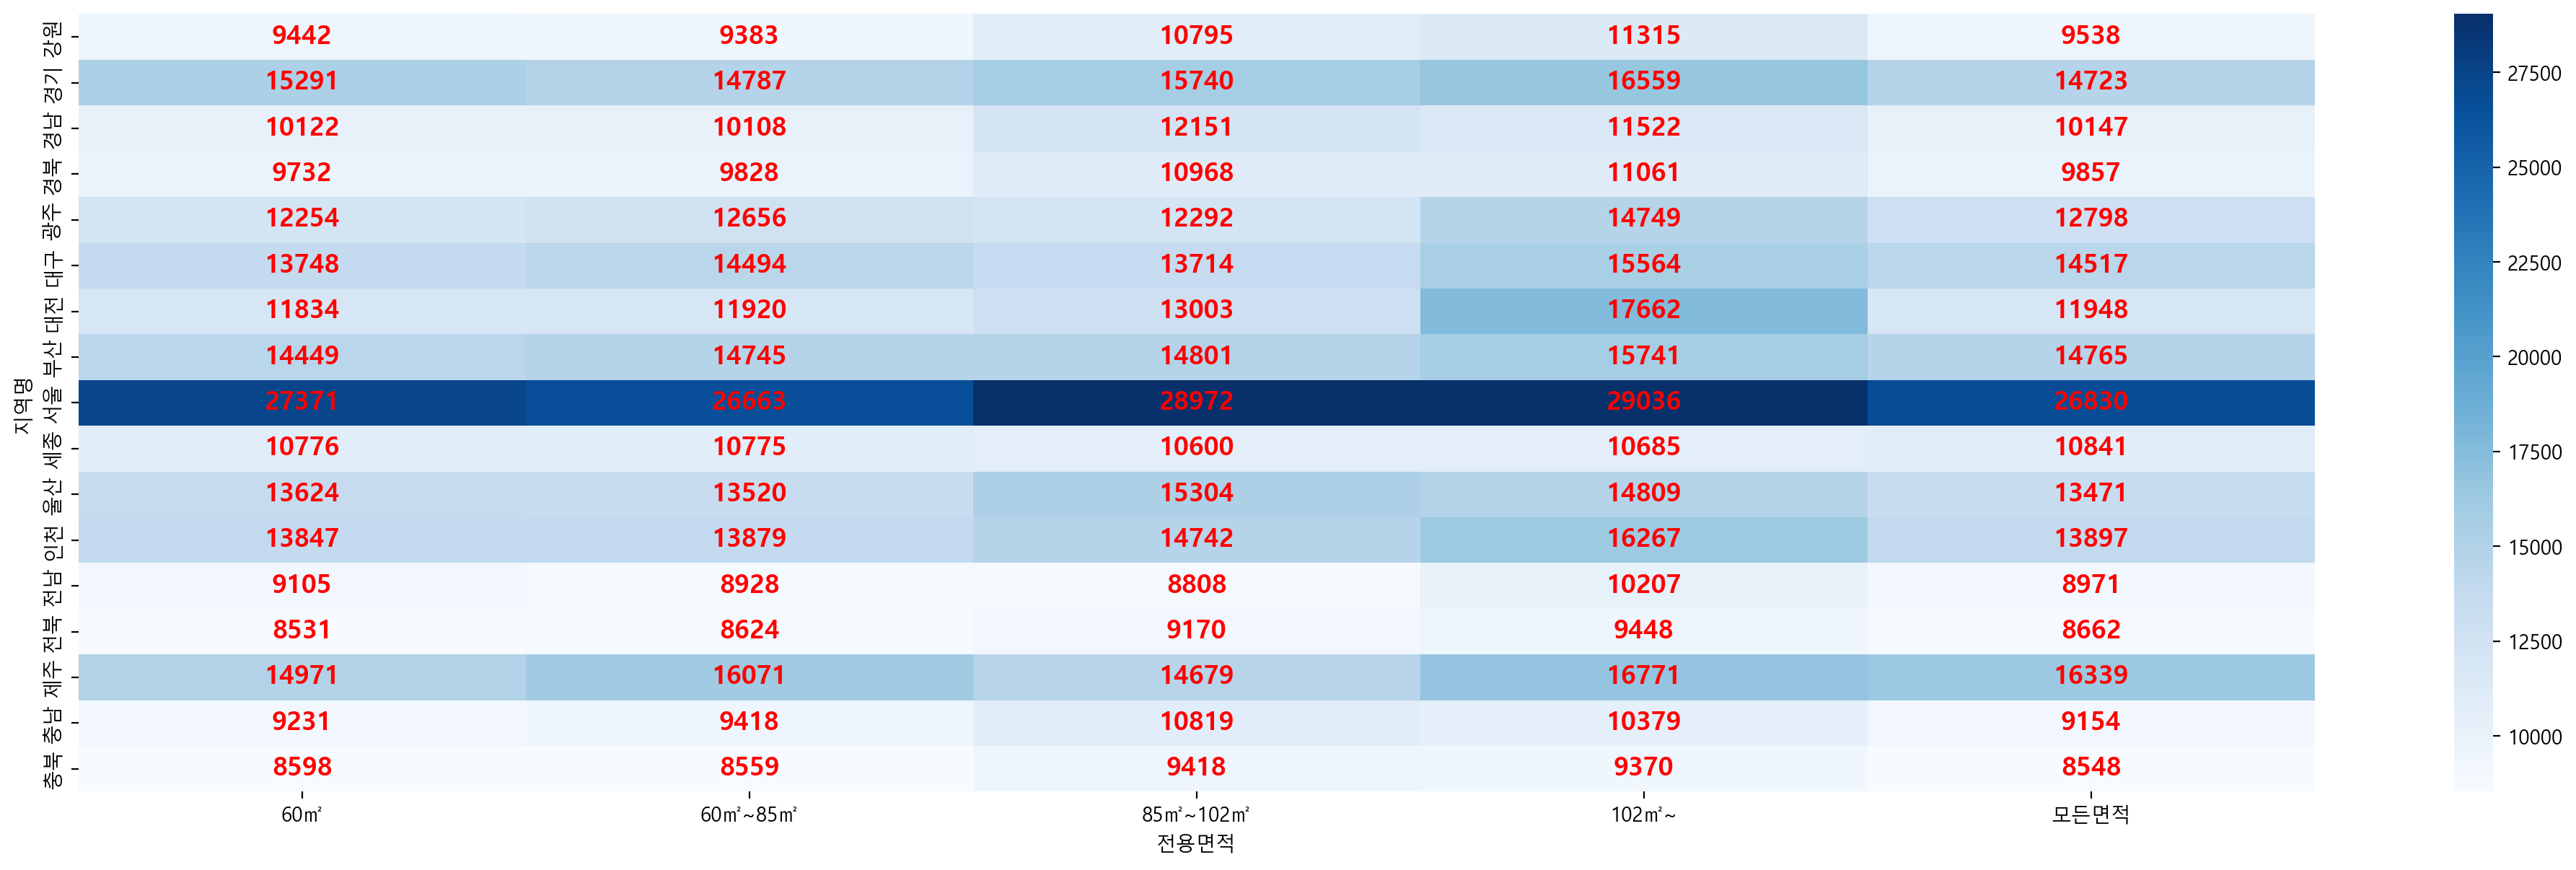

In [312]:
plt.figure(figsize=(25,7))
sns.heatmap(r, cmap='Blues', annot=True, fmt='.0f',
           annot_kws={'size':13, 'weight':'bold', 'color':'red'})

## (5) 연도, 지역별 평당분양가격(평균)

In [309]:
df_last.groupby(['연도','지역명'])['평당분양가격'].mean().unstack().T

연도,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
지역명,,,,,,,,,,
강원,7188.060,7162.903846,7318.850000,8219.255000,8934.475000,10302.423214,10291.325000,11644.215000,13409.385000,15622.282500
경기,11060.940,11684.970000,12296.185000,14258.420000,15665.540000,15106.080000,14567.080000,16621.550000,20175.210000,21532.500000
경남,8459.220,8496.730000,8806.600000,9327.670000,10697.615789,10919.272222,11302.335000,12455.685000,13283.182759,13776.571875
경북,7464.160,7753.405000,8288.063793,8680.776923,9050.250000,9997.693750,11227.150000,12018.050000,13025.320000,14085.355263
광주,7916.700,9190.683333,9599.700000,9526.953333,12111.675000,13406.485714,13709.850000,15095.885106,17957.852830,18548.408108
대구,9018.900,10282.030000,12191.972222,12139.252632,14081.650000,15314.200000,15586.285000,16821.915000,17656.747059,24102.283333
대전,8190.600,8910.733333,9912.910526,10234.106667,12619.200000,11238.844737,11994.216667,14113.880000,17917.288889,19881.922500
부산,10377.400,10743.535000,11637.615000,12889.965000,13537.865000,13353.010000,14317.655000,18166.835593,20470.850847,22900.267500
서울,20315.680,21753.435000,21864.095000,23202.245000,28286.830000,29781.015000,29380.450000,29128.531034,33230.560000,38981.827500


In [318]:
# 문제 3번
df_last.pivot_table(index=['연도', '지역명'],
                    values='평당분양가격',
                    aggfunc='mean').unstack()


평당분양가격                                                       \
지역명             강원         경기            경남            경북            광주   
연도                                                                        
2015   7188.060000  11060.940   8459.220000   7464.160000   7916.700000   
2016   7162.903846  11684.970   8496.730000   7753.405000   9190.683333   
2017   7318.850000  12296.185   8806.600000   8288.063793   9599.700000   
2018   8219.255000  14258.420   9327.670000   8680.776923   9526.953333   
2019   8934.475000  15665.540  10697.615789   9050.250000  12111.675000   
2020  10302.423214  15106.080  10919.272222   9997.693750  13406.485714   
2021  10291.325000  14567.080  11302.335000  11227.150000  13709.850000   
2022  11644.215000  16621.550  12455.685000  12018.050000  15095.885106   
2023  13409.385000  20175.210  13283.182759  13025.320000  17957.852830   
2024  15622.282500  21532.500  13776.571875  14085.355263  18548.408108   

                                                                            \
지역명             대구            대전            부산            서울            세종   
연도                                                                           
2015   9018.900000   8190.600000  10377.400000  20315.680000   8765.020000   
2016  10282.030000   8910.733333  10743.535000  21753.435000   8857.805000   
2017  12191.972222   9912.910526  11637.615000  21864.095000   9132.945763   
2018  12139.252632  10234.106667  12889.965000  23202.245000  10340.463158   
2019  14081.650000  12619.200000  13537.865000  28286.830000  11299.394118   
2020  15314.200000  11238.844737  13353.010000  29781.015000  11628.100000   
2021  15586.285000  11994.216667  14317.655000  29380.450000  12578.060000   
2022  16821.915000  14113.880000  18166.835593  29128.531034  11309.971698   
2023  17656.747059  17917.288889  20470.850847  33230.560000  12278.200000   
2024  24102.283333  19881.922500  22900.267500  38981.827500  19115.800000   

                                                                            \
지역명             울산            인천            전남            전북            제주   
연도                                                                           
2015   9367.600000  10976.020000   6798.880000   7110.400000   7951.075000   
2016   9582.574138  11099.055000   6936.600000   6906.625000   9567.480000   
2017  10630.160870  11672.430000   7413.230000   7406.126316  12628.539623   
2018  10241.400000  11881.532143   7929.845000   8174.595000  11935.968000   
2019  10216.250000  13249.775000   8219.275862   8532.260000  11828.469231   
2020  12837.600000  14982.990000   9562.398214   8559.430000  14192.876923   
2021  14191.953061  15774.330000   9980.760000   9047.928814  22302.342857   
2022  17903.751724  17341.830000  10635.508475  10003.070000  18953.825000   
2023  18832.093220  16150.695000  11846.682692  10966.024528  24095.901923   
2024  17828.765625  21506.347500  13540.415625  12400.941667  25096.087500   

                                  
지역명             충남            충북  
연도                                
2015   7689.880000   6828.800000  
2016   7958.225000   7133.335000  
2017   8157.315517   7462.565000  
2018   8201.820000   8149.295000  
2019   8748.840000   7970.875000  
2020   9139.380000   8358.956897  
2021   9860.741379   8822.385000  
2022  11730.345000  10033.540000  
2023  12580.590000  11103.950000  
2024  12739.650000  12851.767500

<Axes: xlabel='전용면적', ylabel='지역명'>

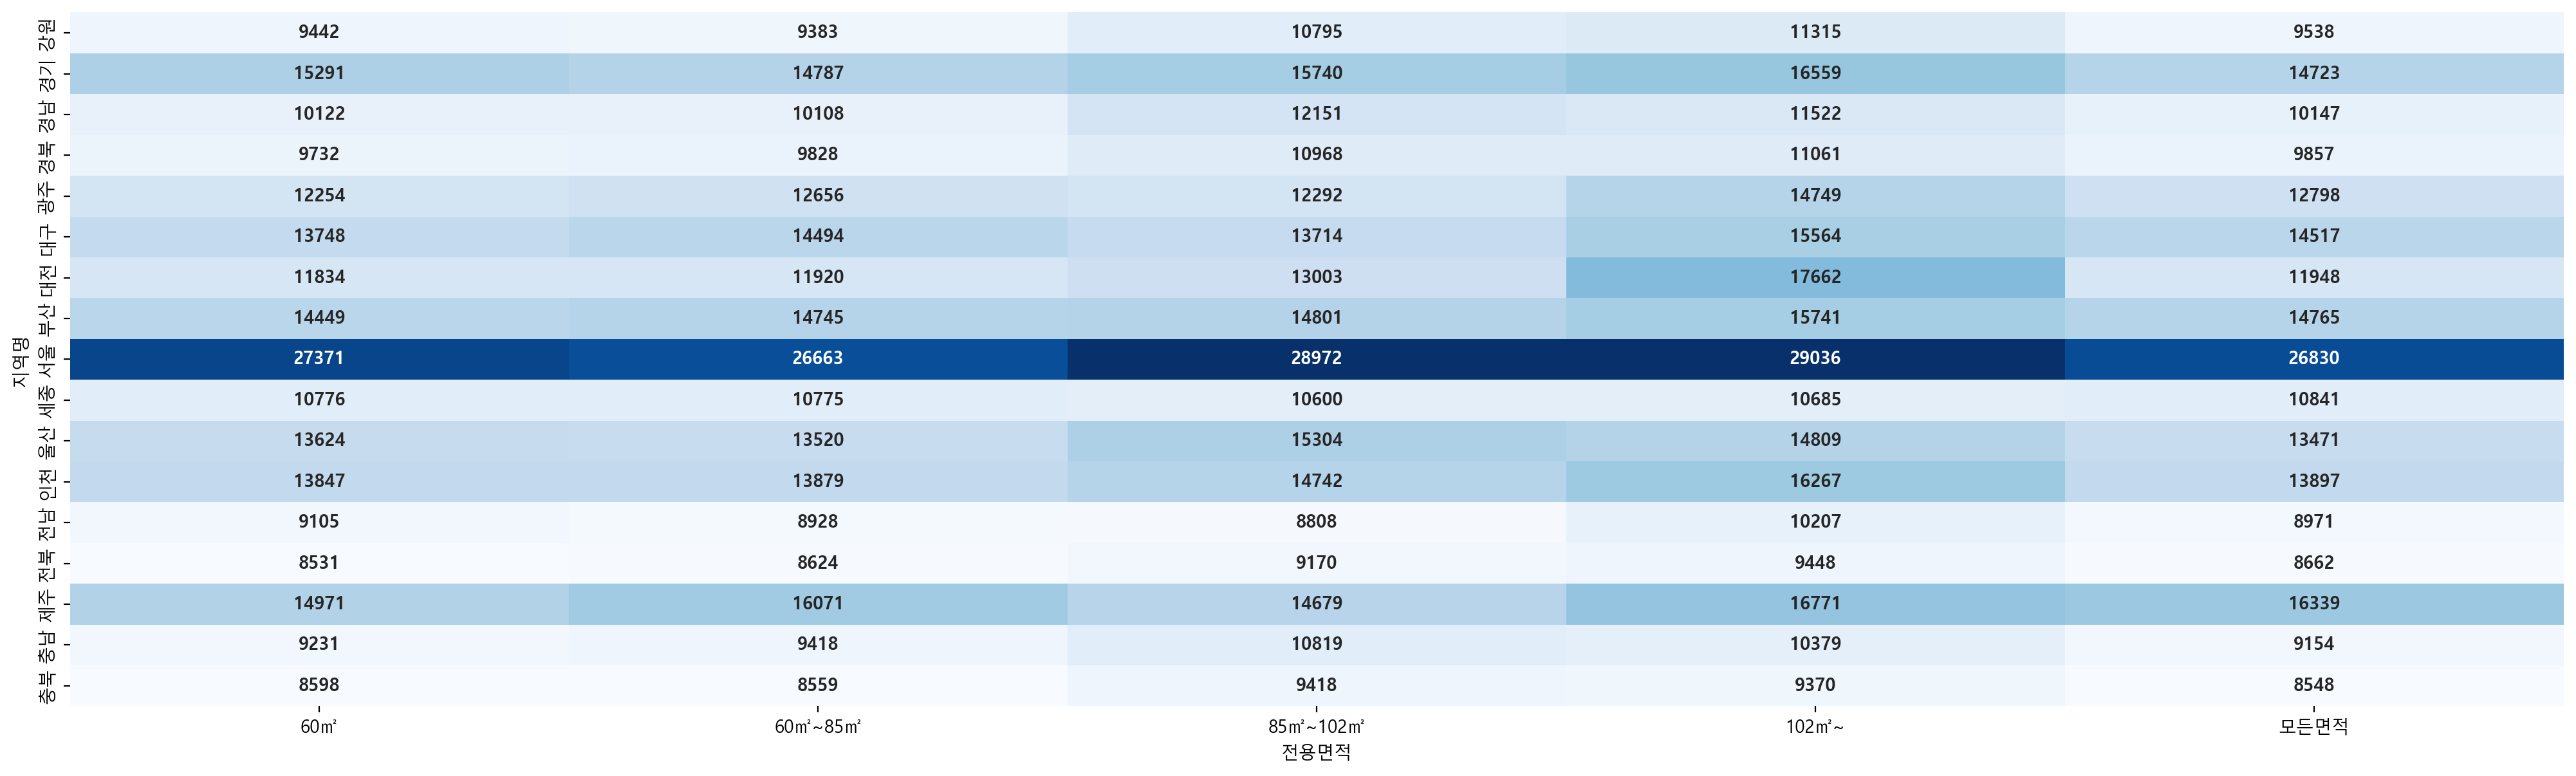

In [314]:
plt.figure(figsize=(25,7))
sns.heatmap(r, cmap='Blues', annot=True, fmt='.0f',
           annot_kws={'weight':'bold'},
           cbar=False)

- color map 참조 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

# 8. matplotlib으로 시각화(위의 도표)
https://www.research.autodesk.com/publications/same-stats-different-graphs/
## (1) 지역별 결측치를 제외한 데이터수(line, bar)

<Axes: xlabel='지역명'>

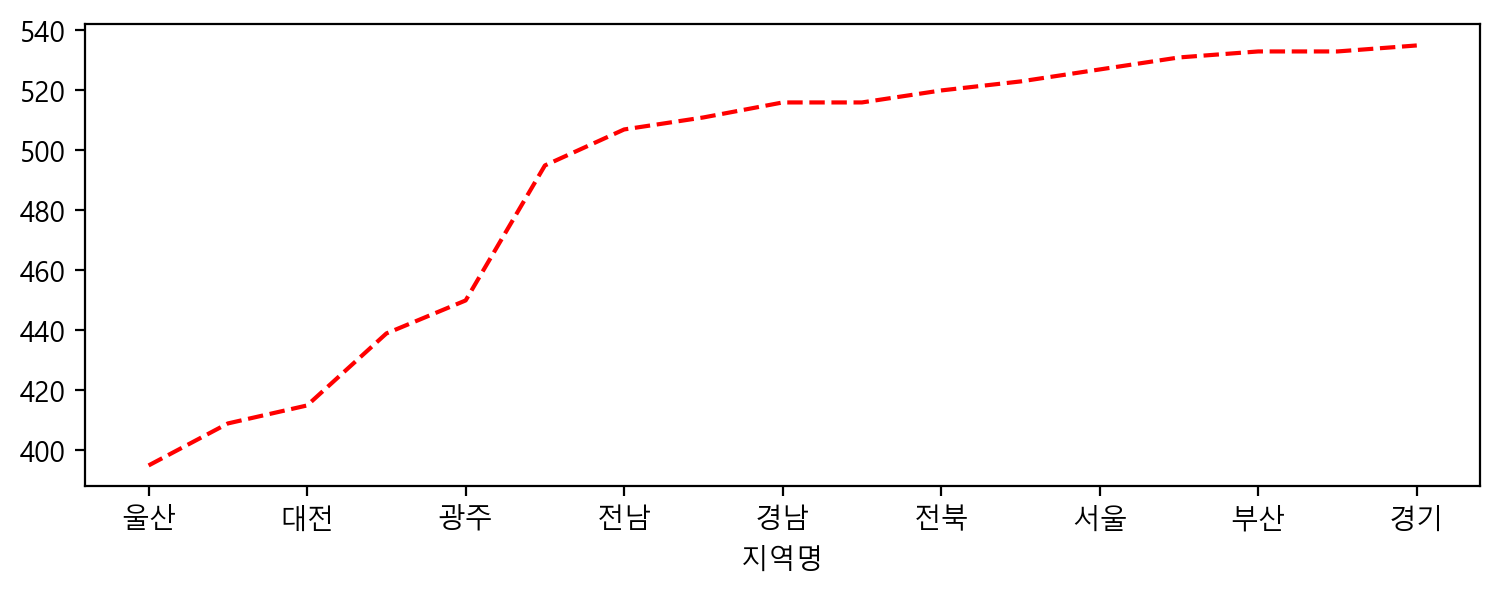

In [330]:
result = df_last.groupby('지역명')['평당분양가격'].count().sort_values()
plt.figure(figsize=(9,3))
result.plot(kind='line', color = 'r', linestyle='--')


<Axes: xlabel='지역명'>

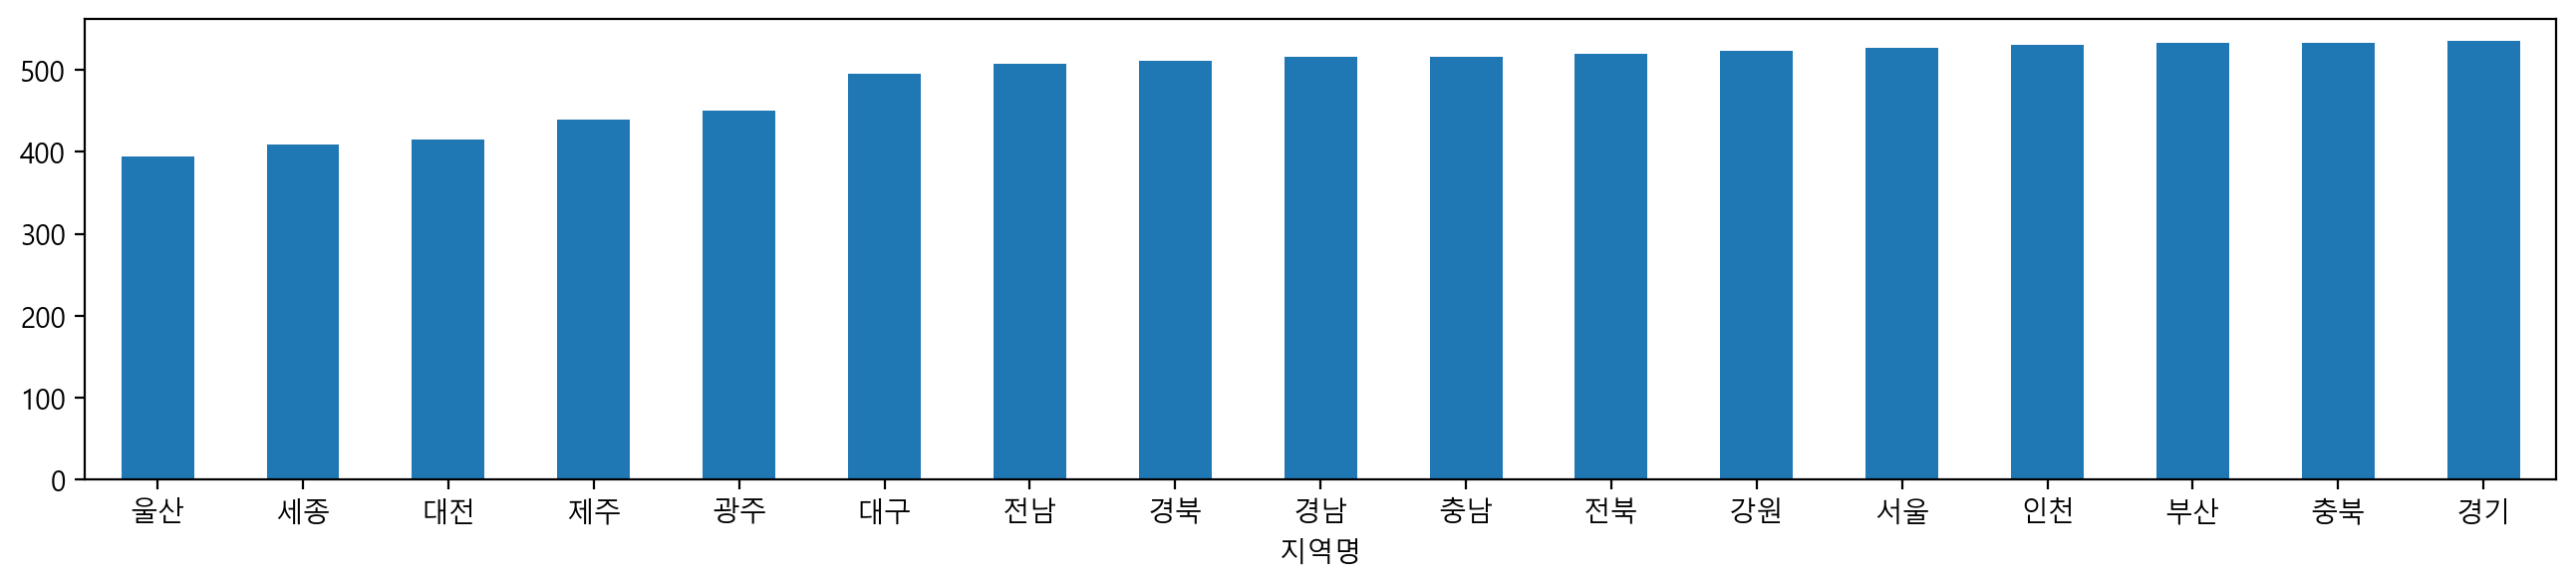

In [331]:
result.plot.bar()
result.plot(kind='bar', figsize=(16,3), rot=0)

## (2) 지역별 평당분양가격 (line, bar)

<Axes: xlabel='지역명'>

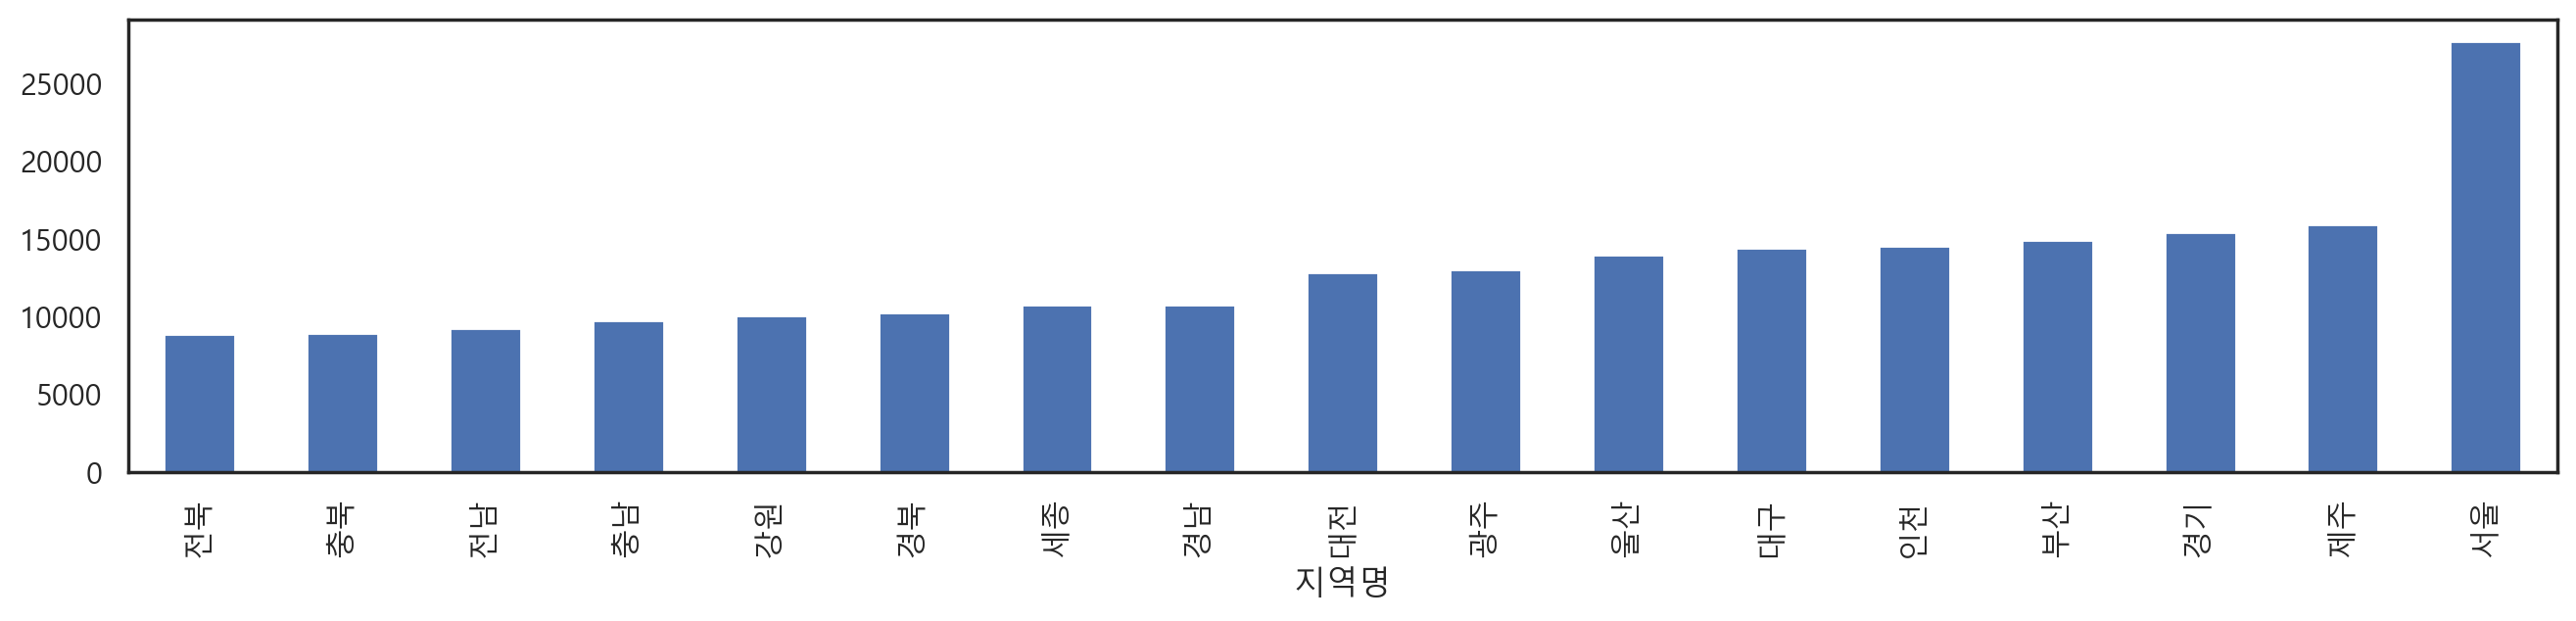

In [101]:
df_last.groupby('지역명')['평당분양가격'].mean().sort_values().plot(kind='bar', figsize=(16,3))

## (3) 전용면적별 평당분양가격(barplot)

In [102]:
df_last.groupby('전용면적')[['평당분양가격']].mean().

SyntaxError: invalid syntax (1803277787.py, line 1)

In [103]:
result = df_last.groupby('전용면적')['평당분양가격'].mean().sort_values()
result


전용면적
60㎡         12522.774427
60㎡~85㎡     12619.048827
모든면적        12654.068098
85㎡~102㎡    13447.672835
102㎡~       14066.826846
Name: 평당분양가격, dtype: float64

In [104]:
for idx, val in enumerate(result):
    print(idx, val)

0 12522.77442680776
1 12619.048826815642
2 12654.068098159509
3 13447.67283519553
4 14066.826845637583


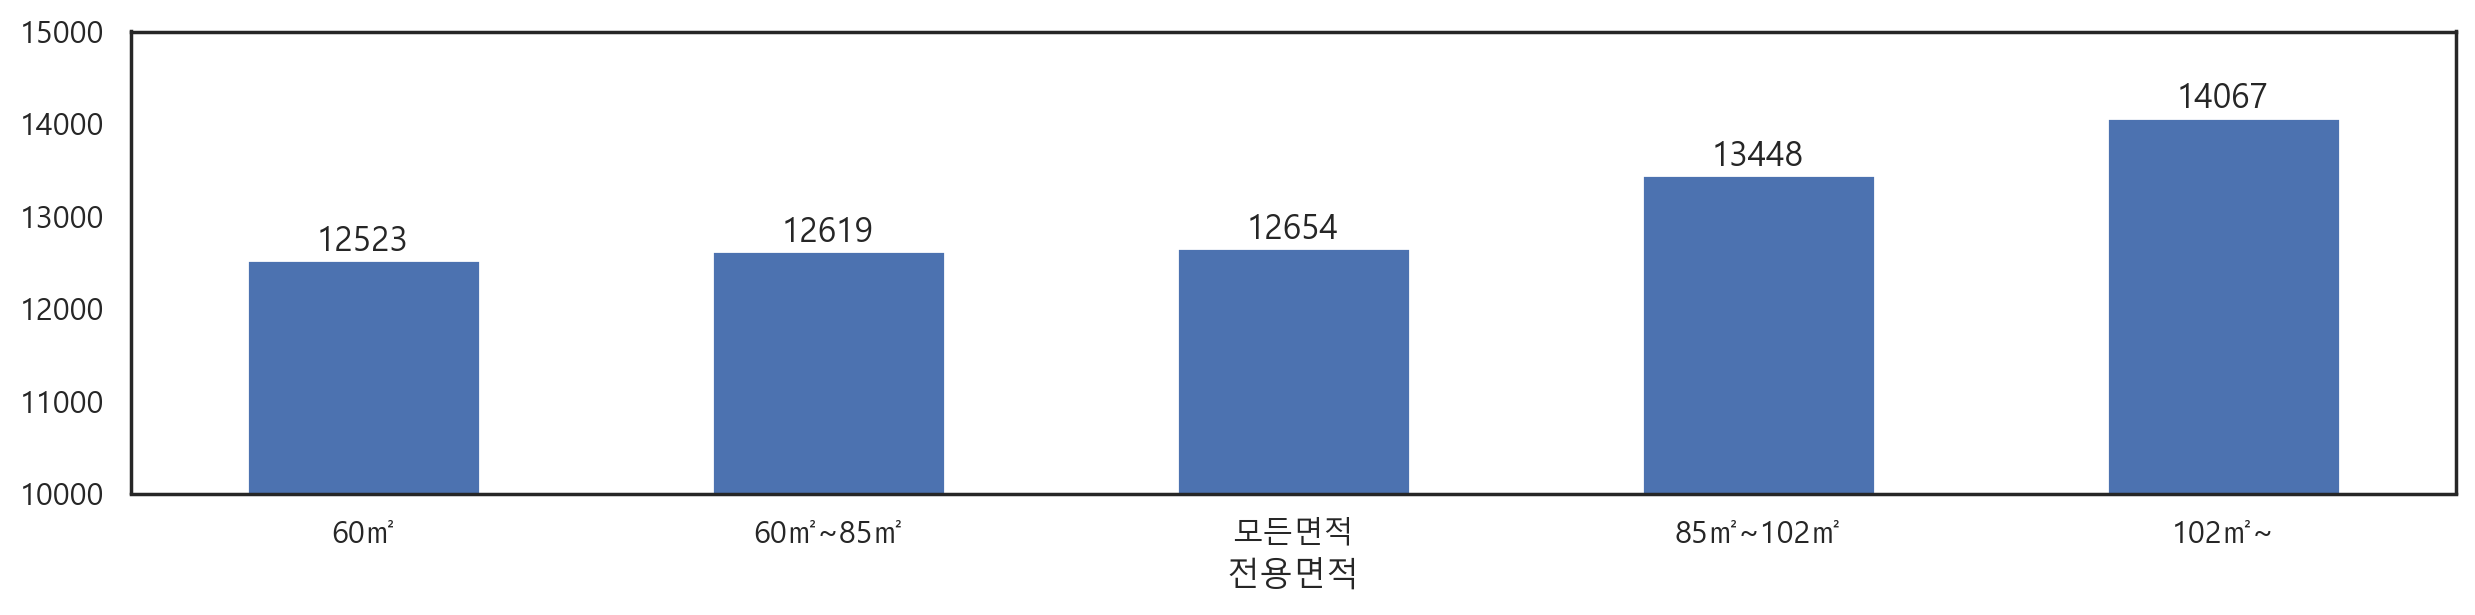

In [105]:
ax = result.plot(kind='bar', figsize=(15,3), rot=0)
ax.set_ylim([10000, 15000])
for idx, val in enumerate(result):
    ax.text(idx-0.1, val+100, round(val))
# ax.text(0-0.1, 12522+100, 12522)
# ax.text(4-0.1, 14066+100, 14066)

## (4) 연도별 평균 평당분양가격(line)

In [106]:
result = df_last.groupby('연도')['평당분양가격'].mean()
result

연도
2015     9202.735802
2016     9683.025000
2017    10372.928923
2018    10978.938411
2019    12188.293092
2020    13039.422449
2021    13636.022540
2022    14942.504494
2023    16890.920657
2024    18962.919231
Name: 평당분양가격, dtype: float64

In [107]:
for year, val in result.items():
    print(year, val)

2015 9202.735802469135
2016 9683.025
2017 10372.928923076923
2018 10978.938411316649
2019 12188.293092105261
2020 13039.42244897959
2021 13636.022539682539
2022 14942.504494382021
2023 16890.92065677966
2024 18962.91923076923


In [108]:
for year, val in zip(result.index, result):
    print(year, val)

2015 9202.735802469135
2016 9683.025
2017 10372.928923076923
2018 10978.938411316649
2019 12188.293092105261
2020 13039.42244897959
2021 13636.022539682539
2022 14942.504494382021
2023 16890.92065677966
2024 18962.91923076923


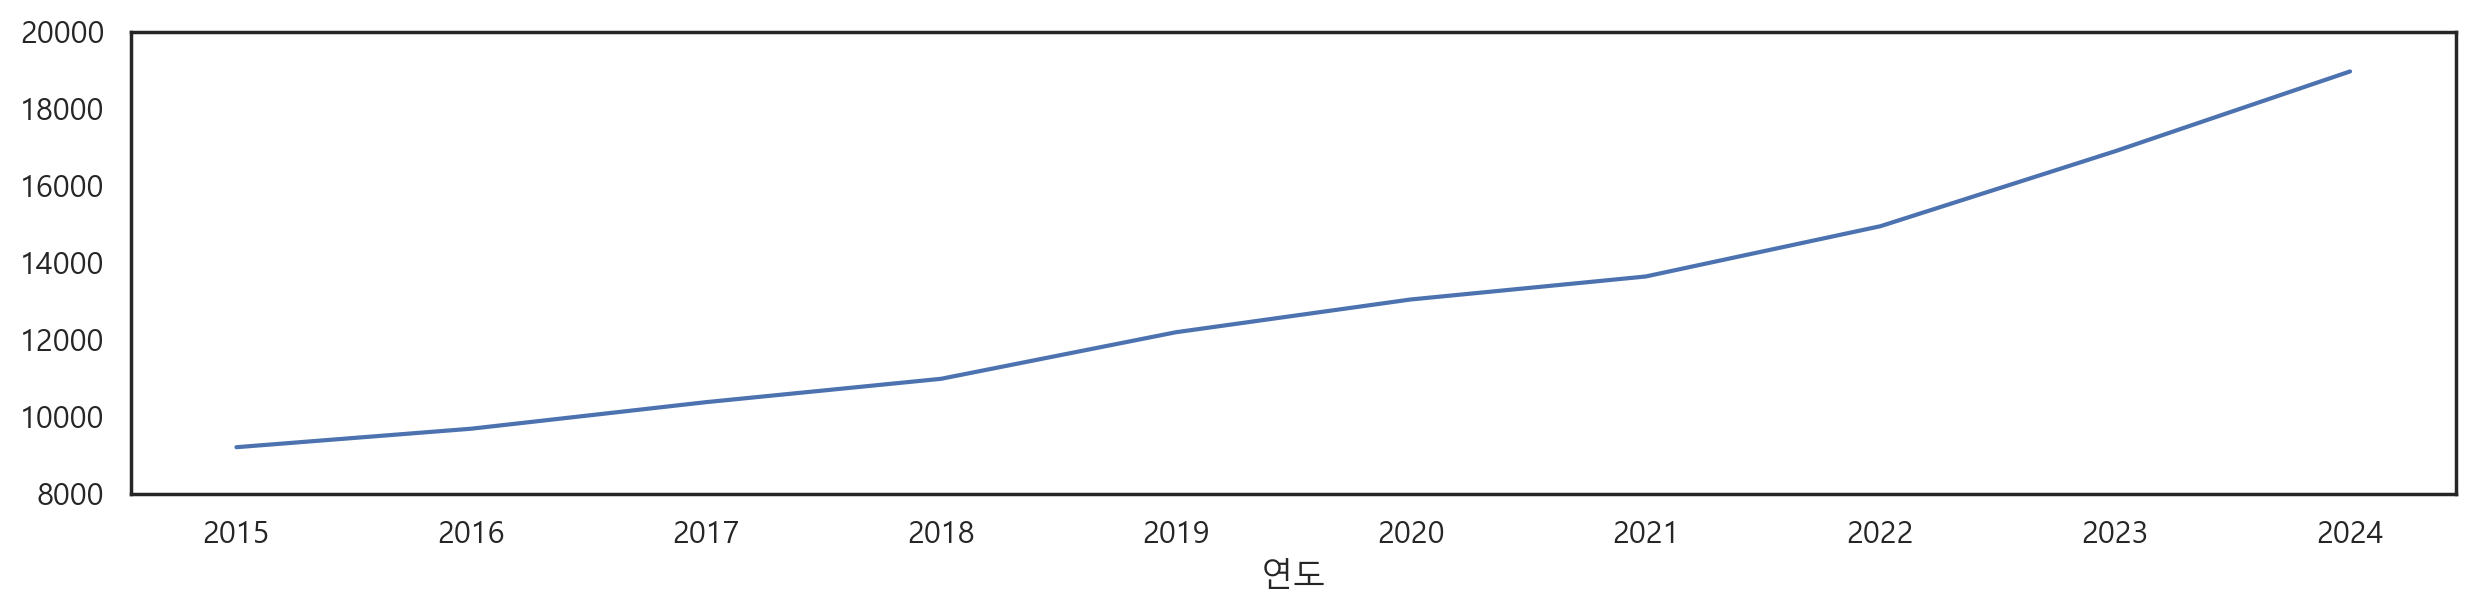

In [109]:
result.plot(kind='line',figsize=(15,3))
plt.ylim([8000,20000])
plt.xticks(range(2015,2025))

plt.show()

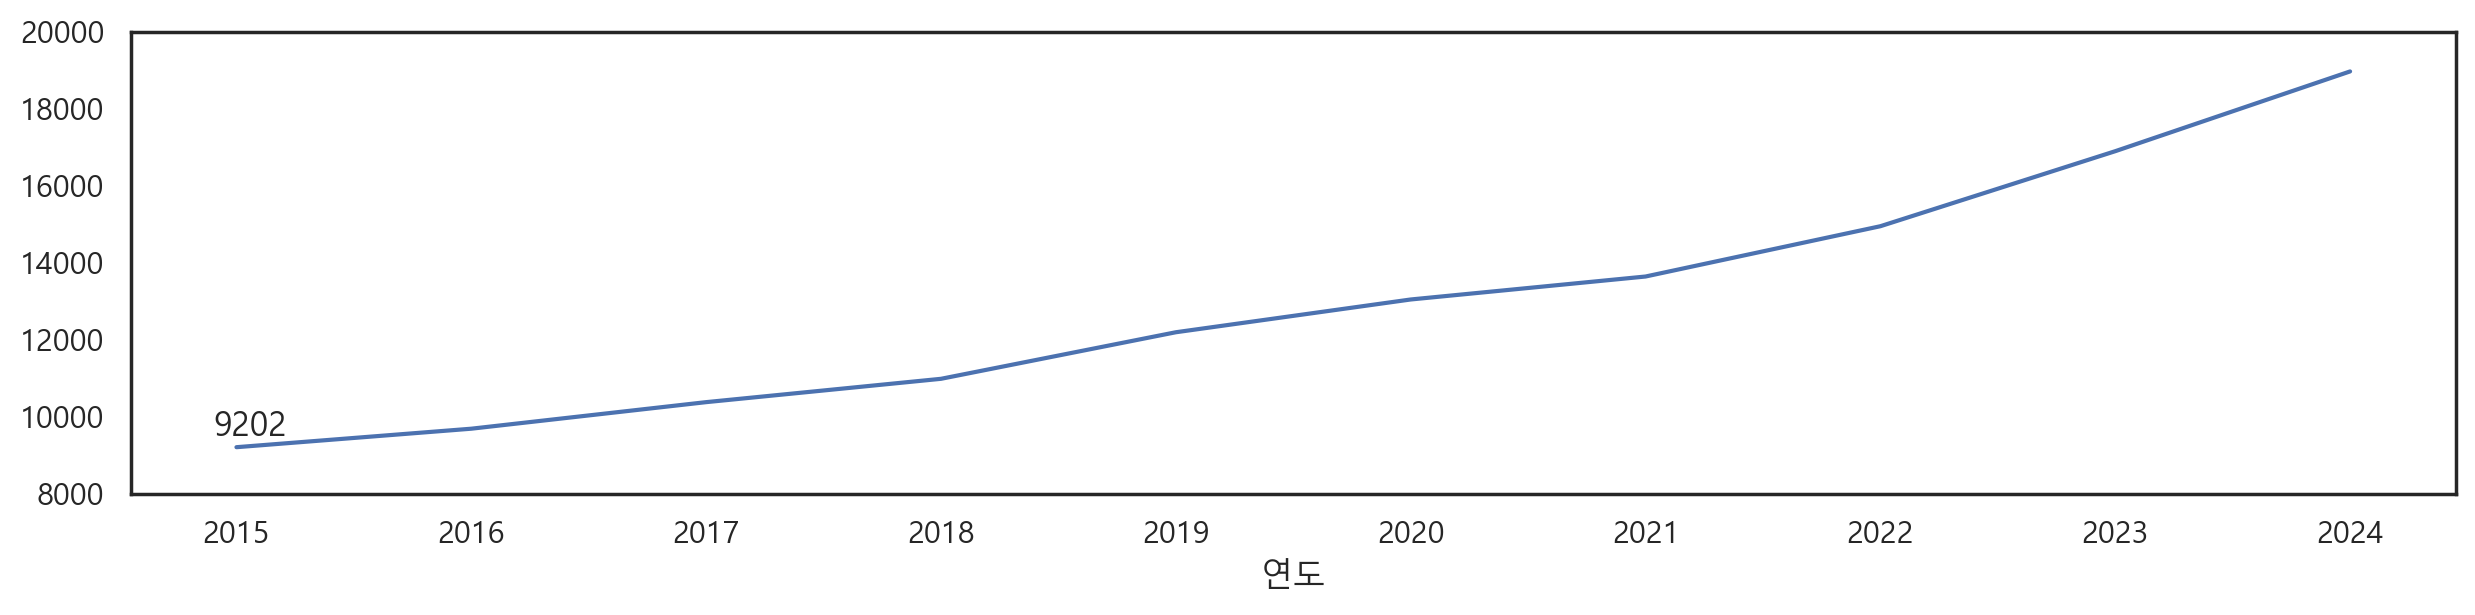

In [110]:
result.plot(kind='line',figsize=(15,3))
plt.ylim([8000,20000])
plt.xticks(range(2015,2025))

plt.text(2015-0.1, 9202+300, 9202)
plt.show()

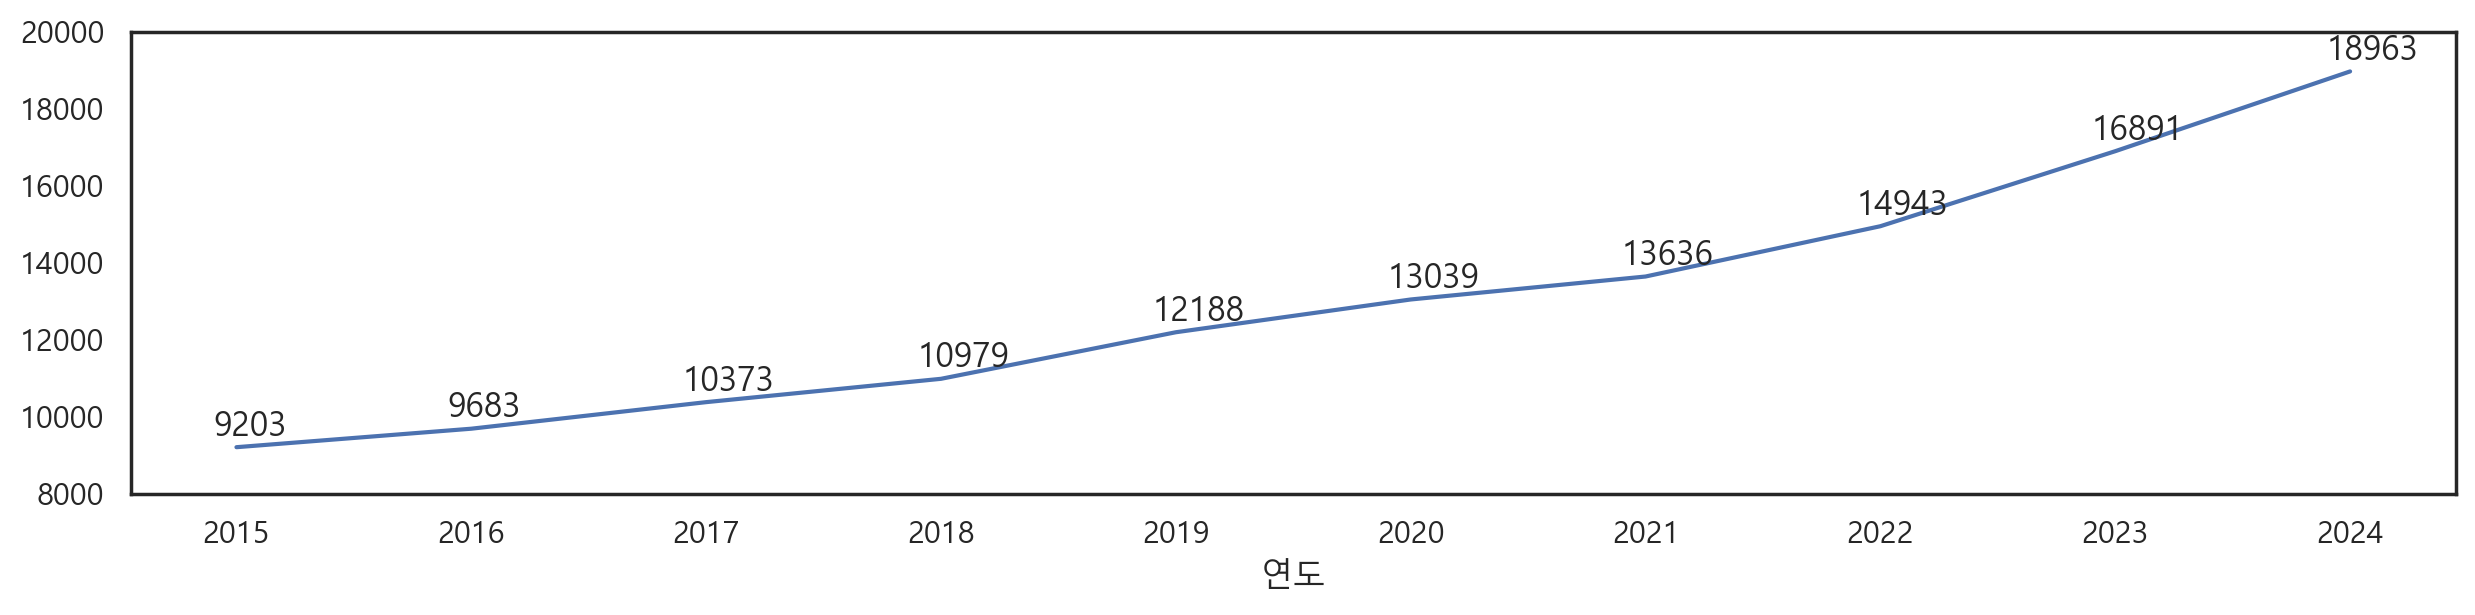

In [111]:
result.plot(kind='line',figsize=(15,3))
plt.ylim([8000,20000])
plt.xticks(range(2015,2025))
for year, val in result.items():
    plt.text(year-0.1, val+300, round(val))
plt.show()

범례:https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot

# 9. seaborn으로 시각화
- 위에서 시각화한 내용을 seaborn으로 시각화

In [112]:
sns.set(style='white', rc={'figure.figsize':(12,3)})
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

## (1) 지역별 평당분양가격

<Axes: xlabel='지역명', ylabel='평당분양가격'>

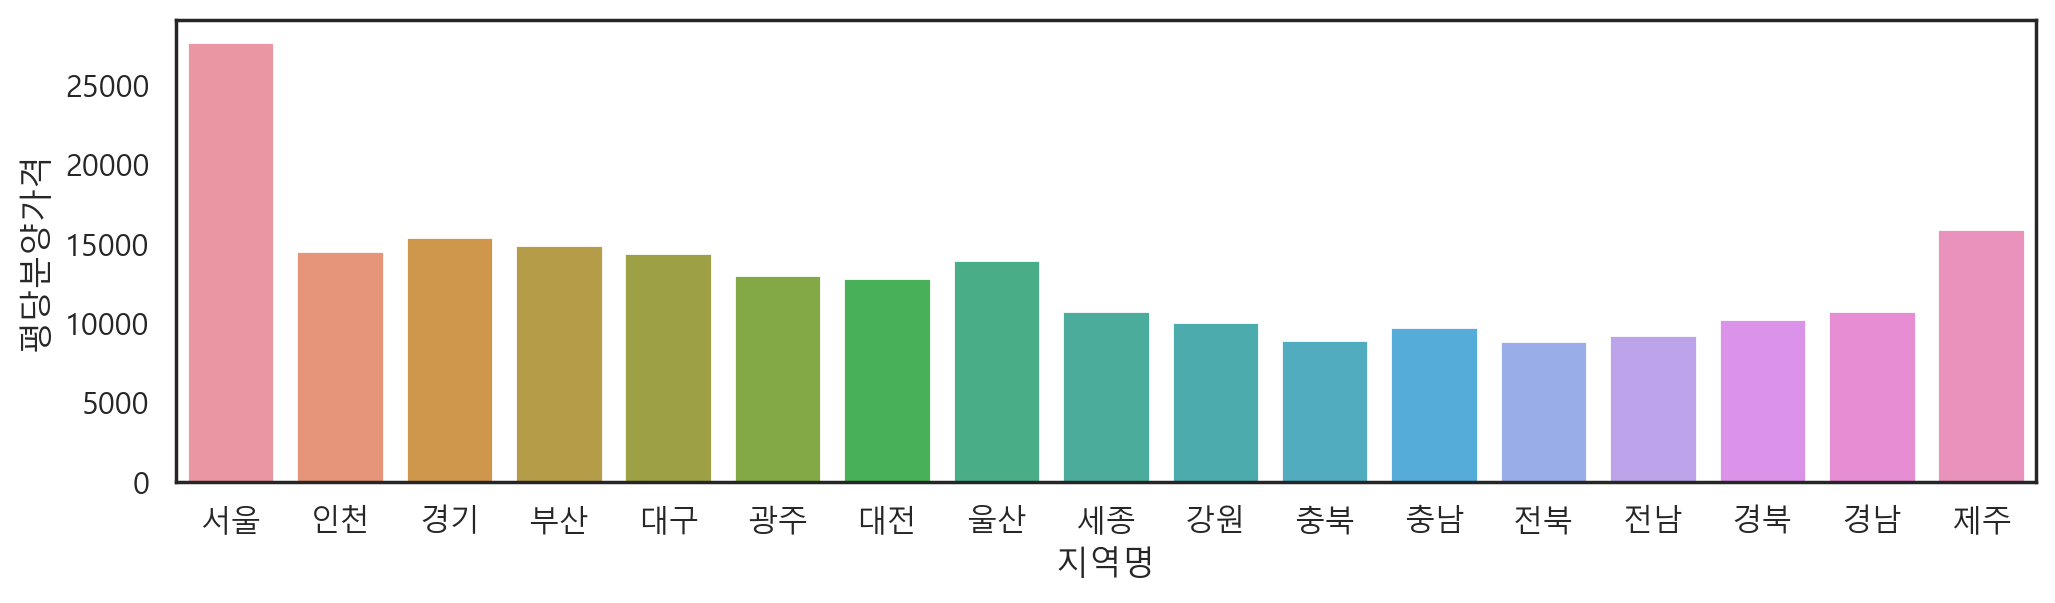

In [113]:
sns.barplot(data=df_last, x='지역명', y='평당분양가격',
           errorbar=None
           )

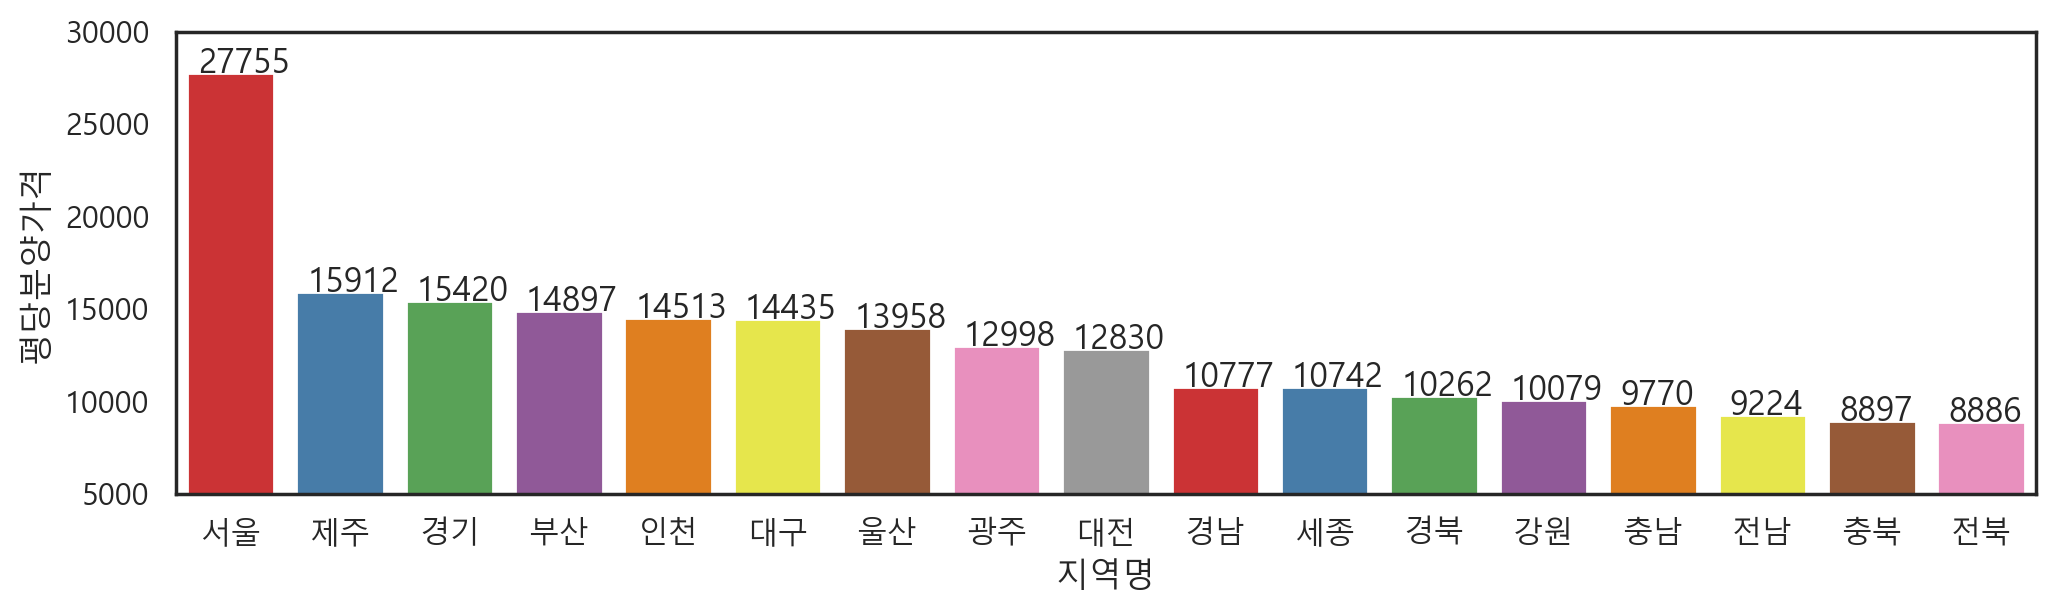

In [114]:
# 위 barplot + sort + 값annot
result = df_last.groupby('지역명')['평당분양가격'].mean().sort_values(ascending=False)
result.index
sns.barplot(data=df_last, x='지역명', y='평당분양가격',
            order=result.index,
           errorbar=None,
           palette='Set1')
for idx, val in enumerate(result):
    plt.text(idx-0.3,val,round(val))
plt.ylim([5000,30000])
plt.show()

In [115]:
for idx,val in enumerate(result):
    print(idx, val)

0 27755.404554079694
1 15912.434624145786
2 15420.03028037383
3 14896.949155722325
4 14513.23220338983
5 14434.519999999999
6 13958.197974683544
7 12998.215999999999
8 12829.565060240964
9 10776.95581395349
10 10741.830806845965
11 10261.553424657533
12 10078.71739961759
13 9769.541279069766
14 9224.326627218934
15 8896.58330206379
16 8886.201923076924


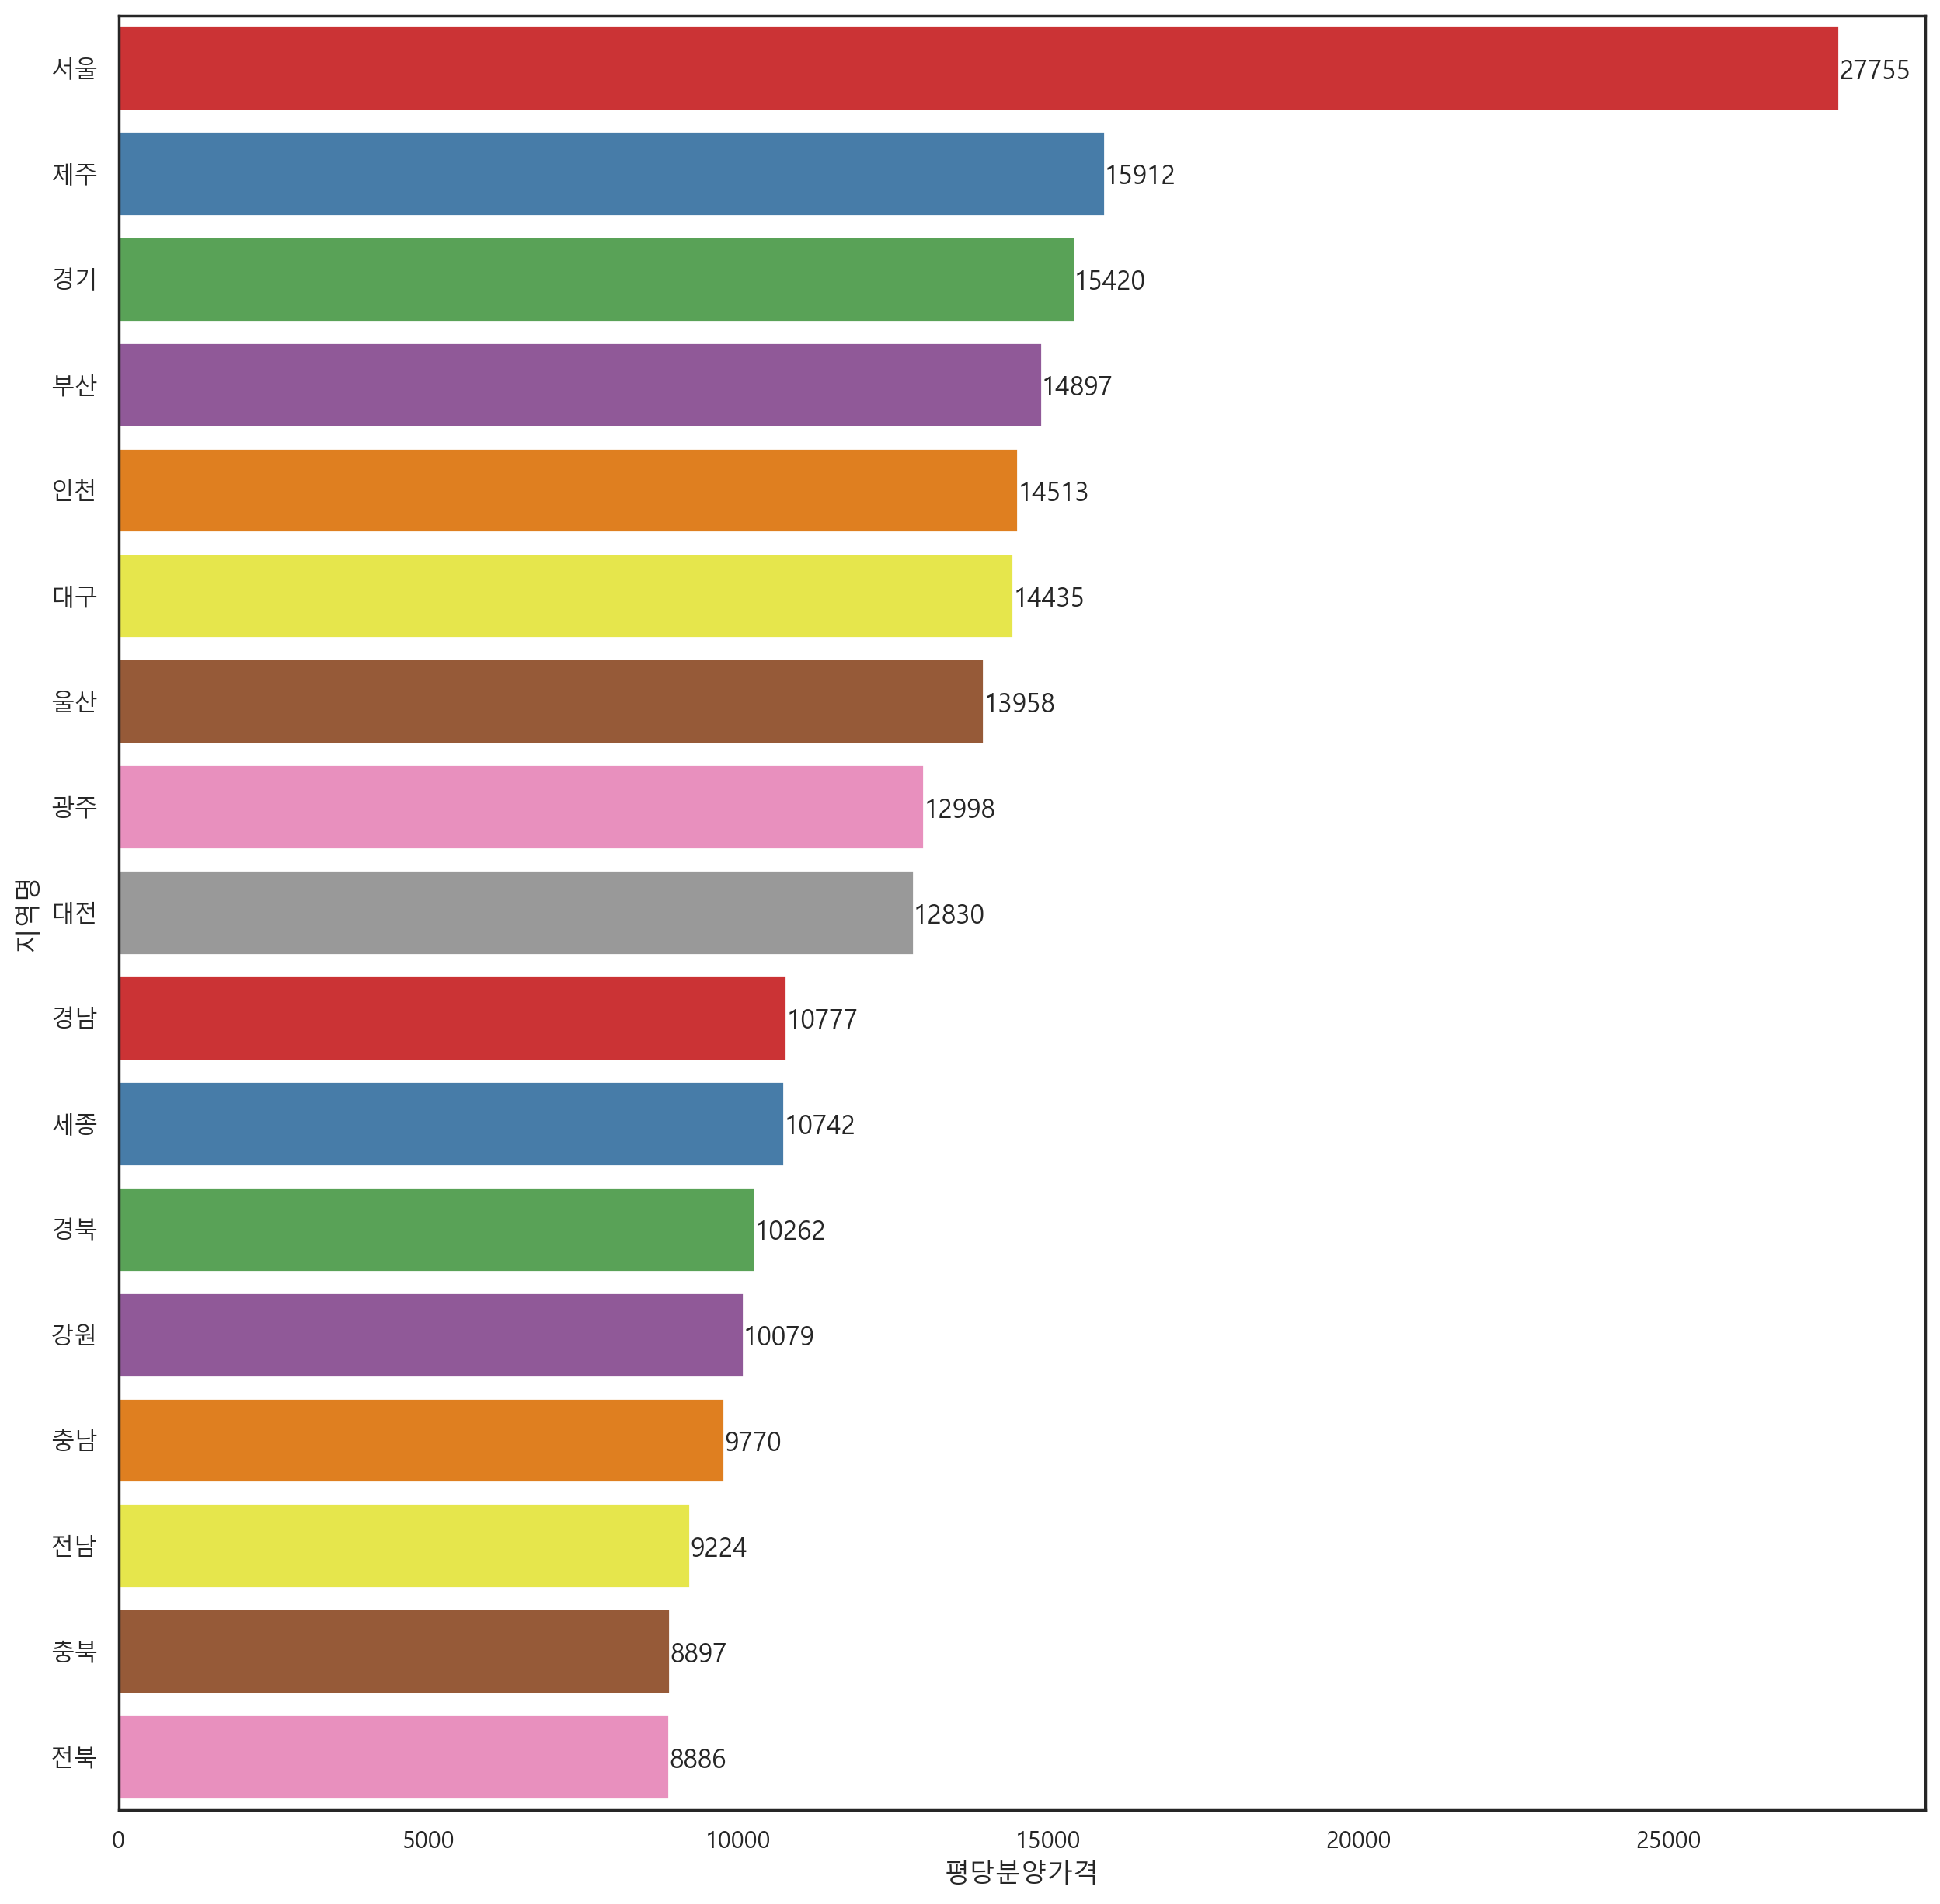

In [116]:
# 가로 barplot
plt.figure(figsize=(15,15))
sns.barplot(data=df_last, y='지역명', x='평당분양가격',
            order=result.index,
            errorbar=None,
            palette='Set1')
for idx, val in enumerate(result):
    plt.text(val,idx+0.1,round(val))
plt.show()

## (2) 연도별 평당분양가격

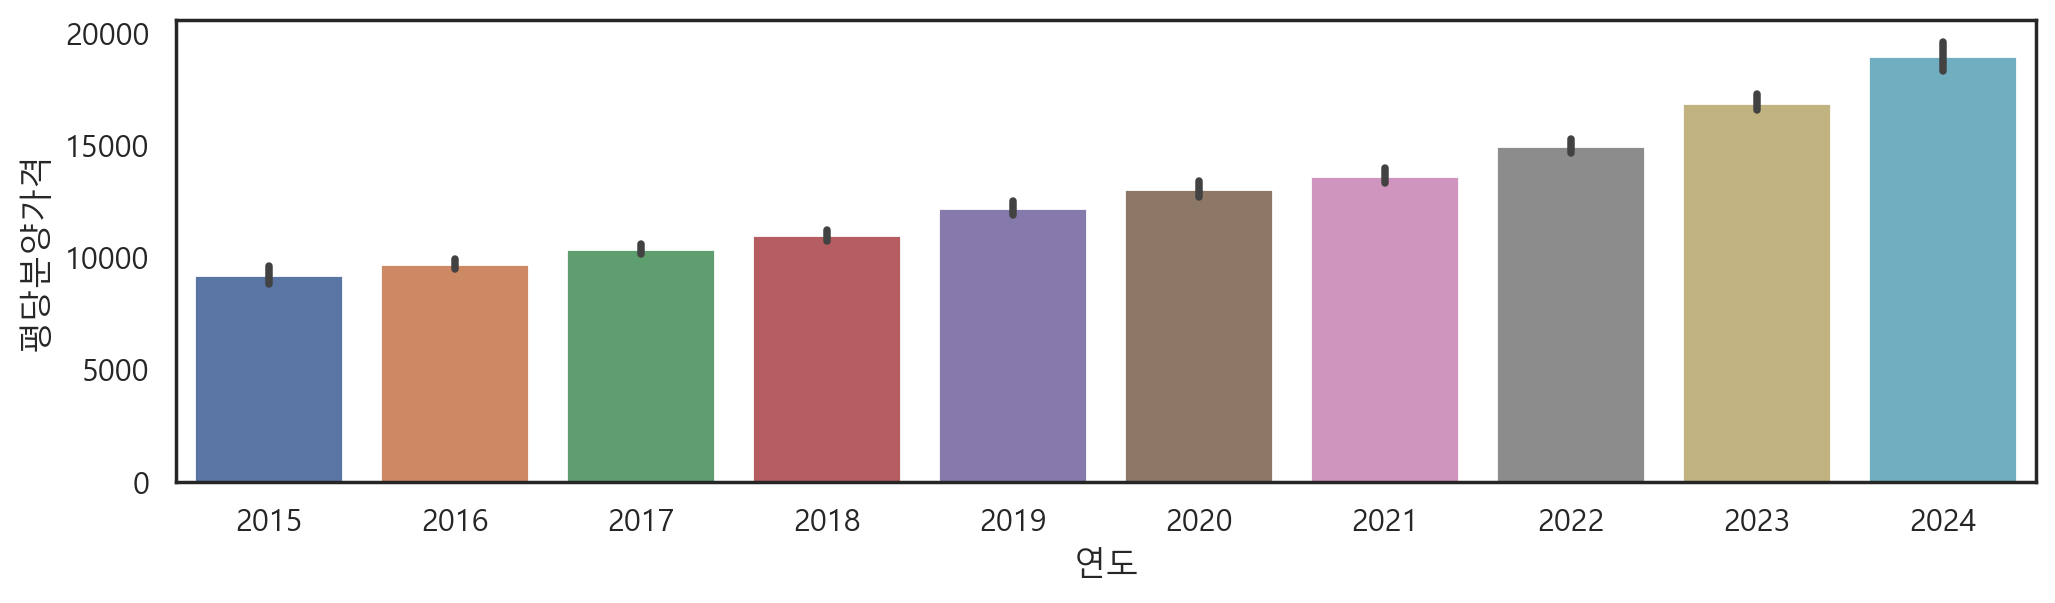

In [117]:
sns.barplot(data=df_last, x='연도', y='평당분양가격')
plt.show()

## (3) 그 외 lineplot, relplot, boxplot, violinplot, boxenplot, regplot, swarmplot

C:\Users\Admin\anaconda3\lib\site-packages\seaborn\utils.py:456: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  handles = old_legend.legendHandles


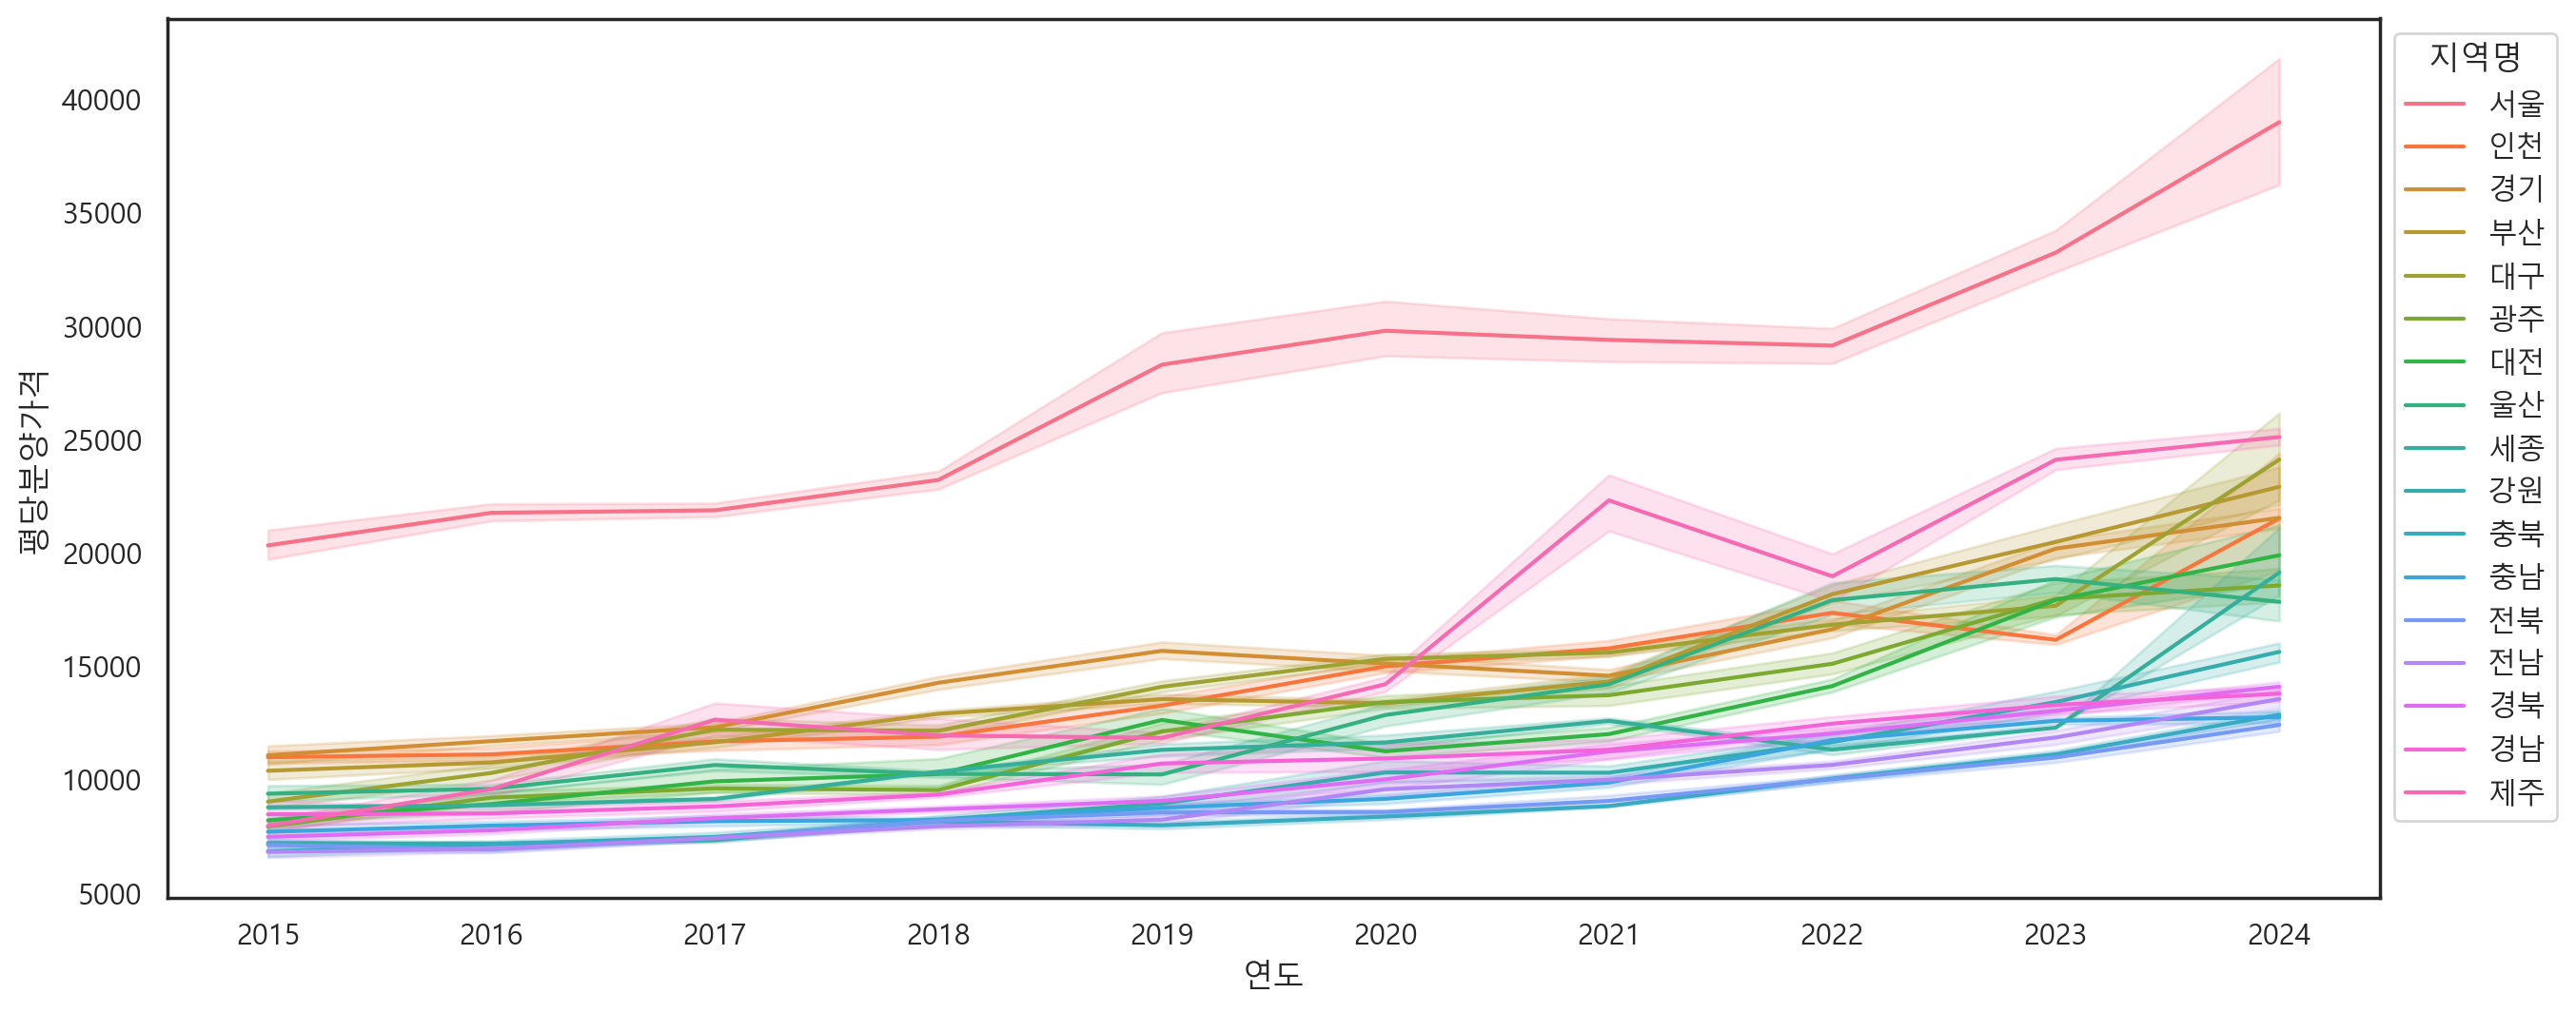

CPU times: total: 4.67 s
Wall time: 4.65 s


In [118]:
%%time
# 년도별 평당분양가격의 추이(lineplot)
plt.figure(figsize=(15,6))
ax = sns.lineplot(data=df_last, x='연도', y='평당분양가격', hue='지역명')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.xticks(range(2015,2025))
plt.show()

C:\Users\Admin\anaconda3\lib\site-packages\seaborn\utils.py:456: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  handles = old_legend.legendHandles


TypeError: Legend.__init__() got an unexpected keyword argument 'bbpx_to_anchor'

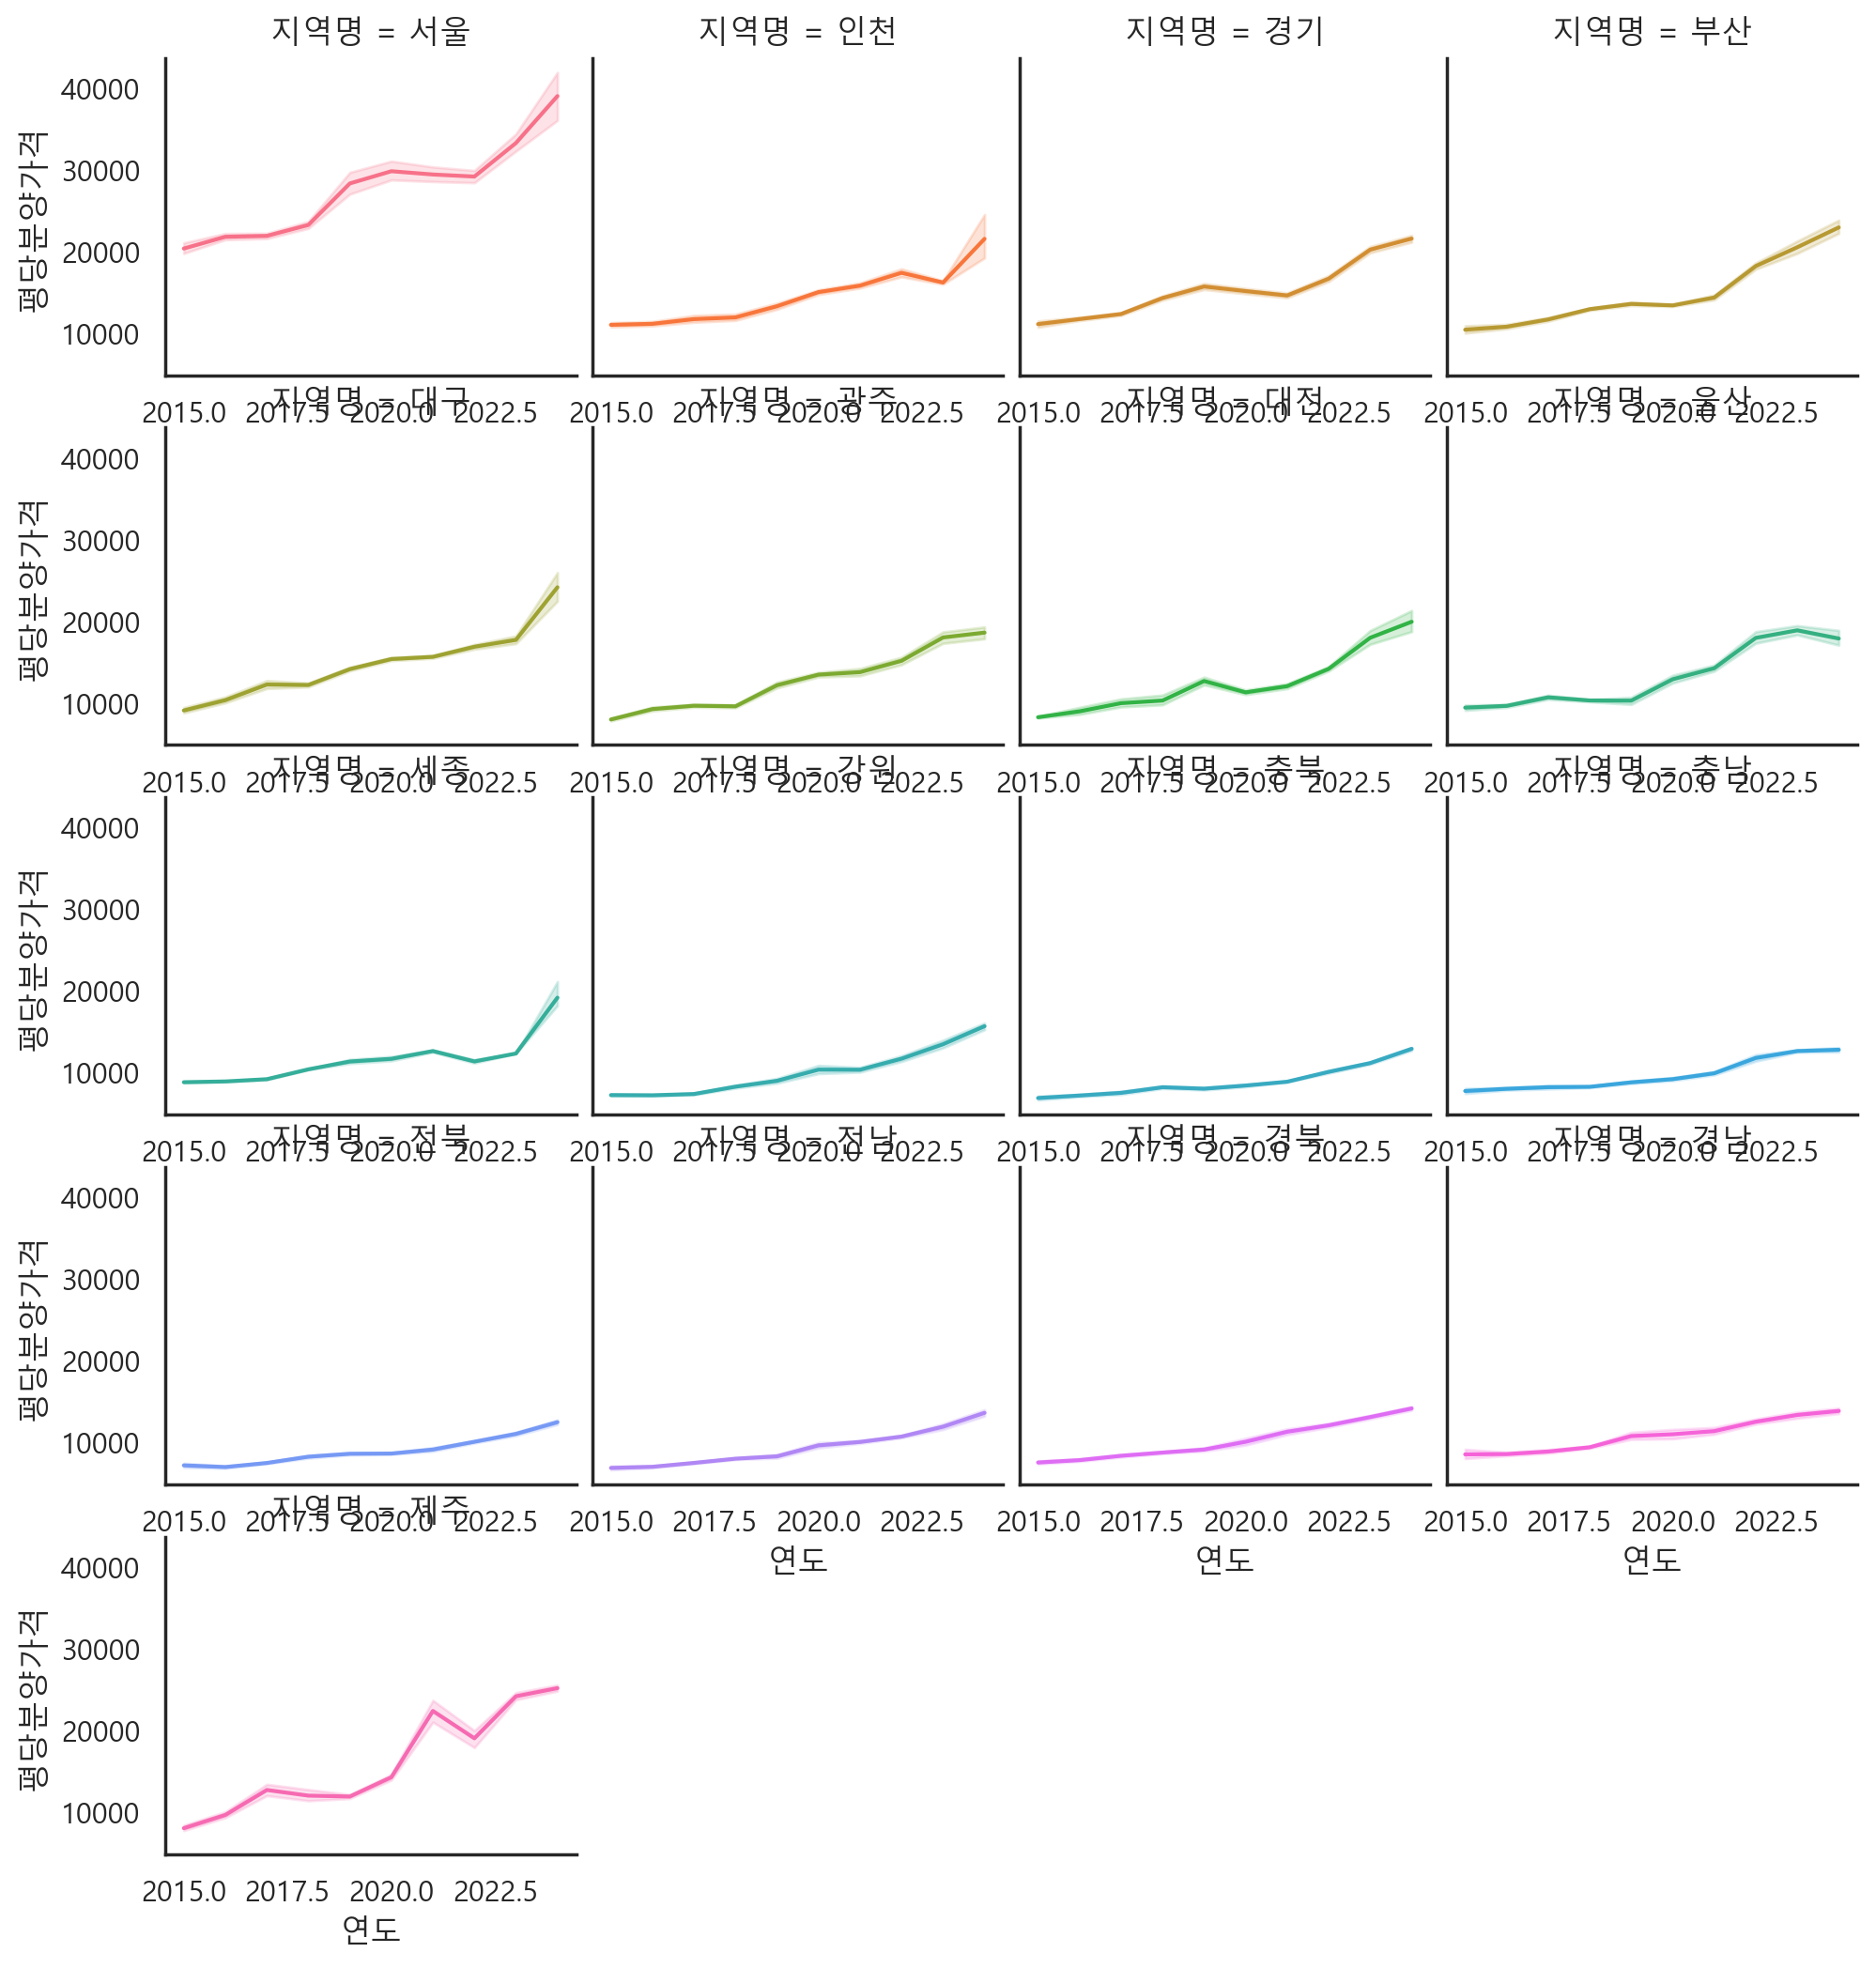

In [119]:
%%time
# 년도별 평당분양가격의 추이(lineplot) - 지역별 서브플룻
g = sns.relplot(data=df_last, x='연도', y='평당분양가격',
           hue='지역명',
           kind='line',
           col='지역명',
           col_wrap=4,
           facet_kws={'sharex':False, 'sharey':True})   # x 축과 y 축을 교정하냐
g.fig.set_size_inches(10,10)  # 서브플롯 사이즈 조정
sns.move_legend(g, 'upper left', bbpx_to_anchor=(1,1))
plt.xticks(range(2015,20025))

<Axes: xlabel='연도', ylabel='평당분양가격'>

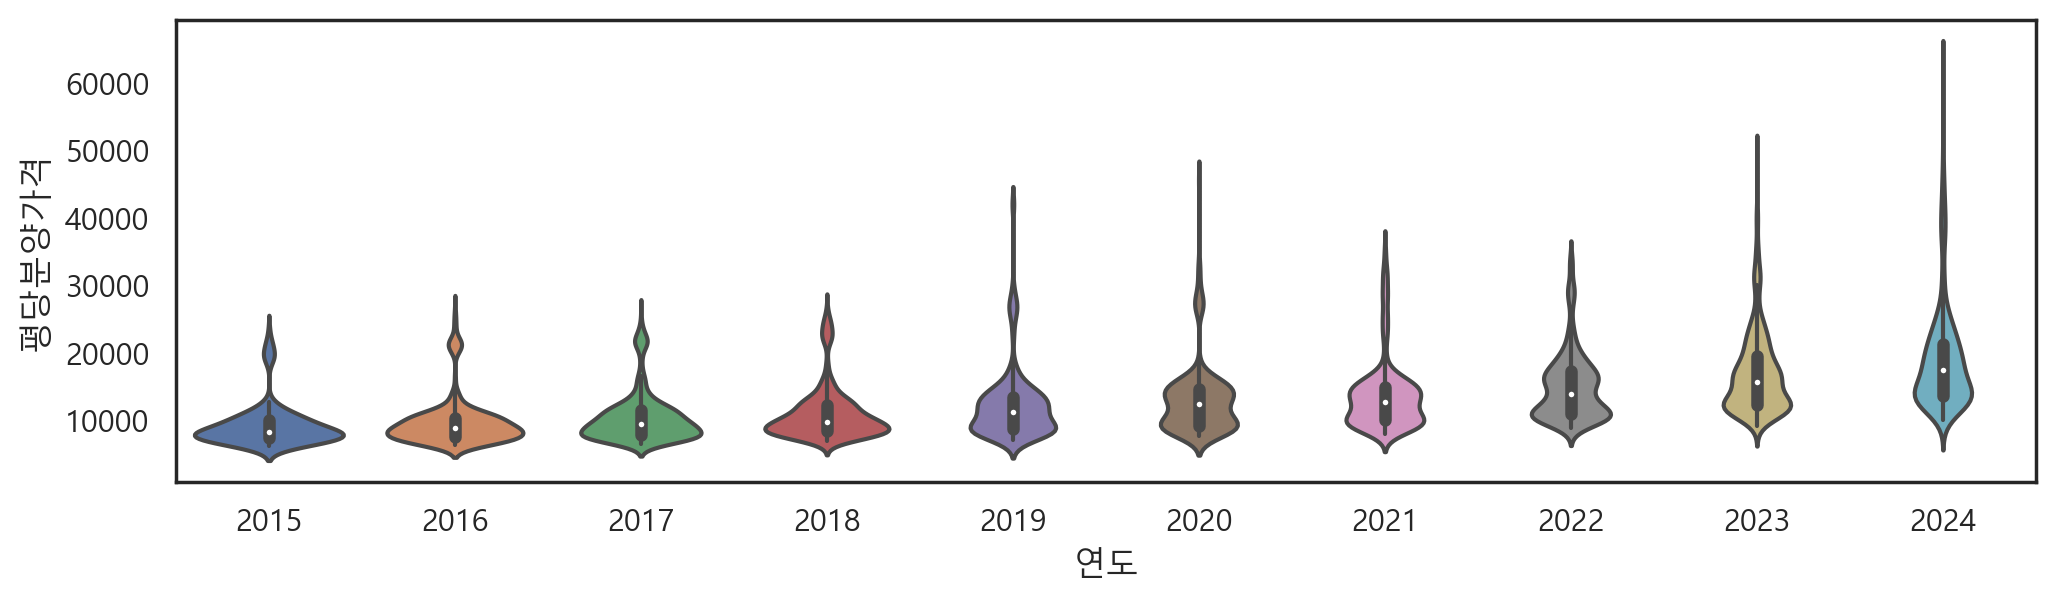

In [121]:
#문제 4번
sns.violinplot(data=df_last, x='연도', y='평당분양가격')

In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# 선명도 높임
%config InlineBackend.figure_format = 'retina'
sns.set(style='white' ,rc={'figure.figsize':(15,3)})
plt.rc('font',family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
# warning 숨기기
import warnings
warnings.filterwarnings(action='ignore')

# 데이터
df_last = pd.read_csv('data/df_last.csv')
df_last.sample(1)

,연도,월,지역명,평당분양가격,전용면적
1705,2017,6,인천,10975.8,모든면적


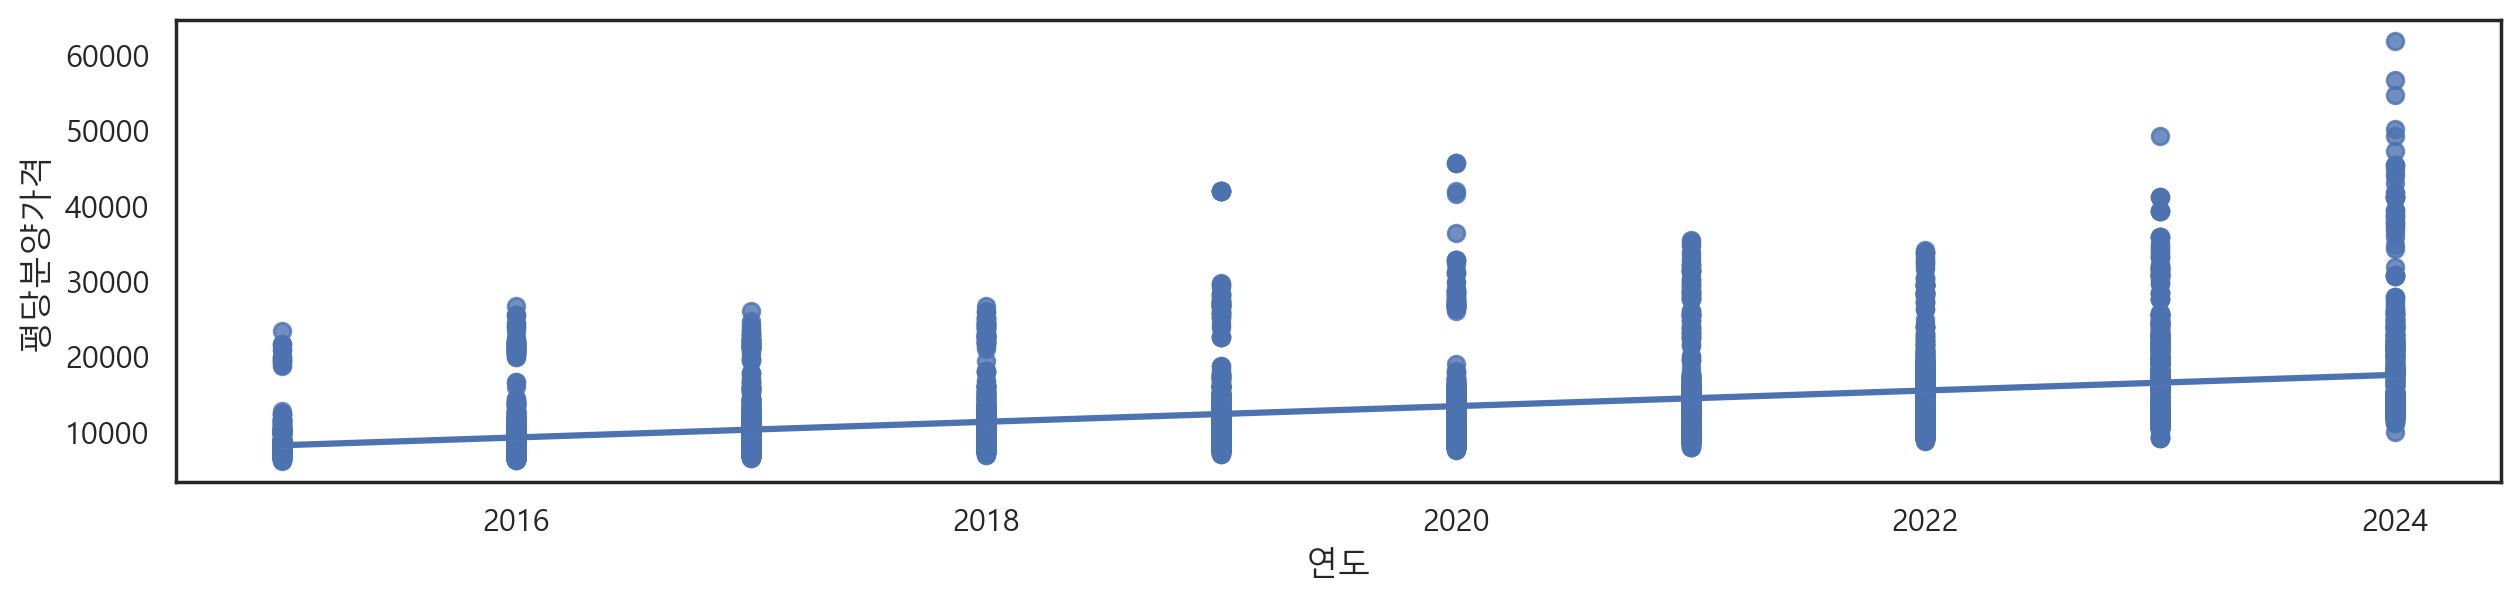

In [5]:
# 연도에 따른 평당분양가격을 회귀식으로 시각화(regplot)  hue 기능을 사용하지 못함
sns.regplot(data=df_last, x = '연도', y = '평당분양가격')
plt.show()

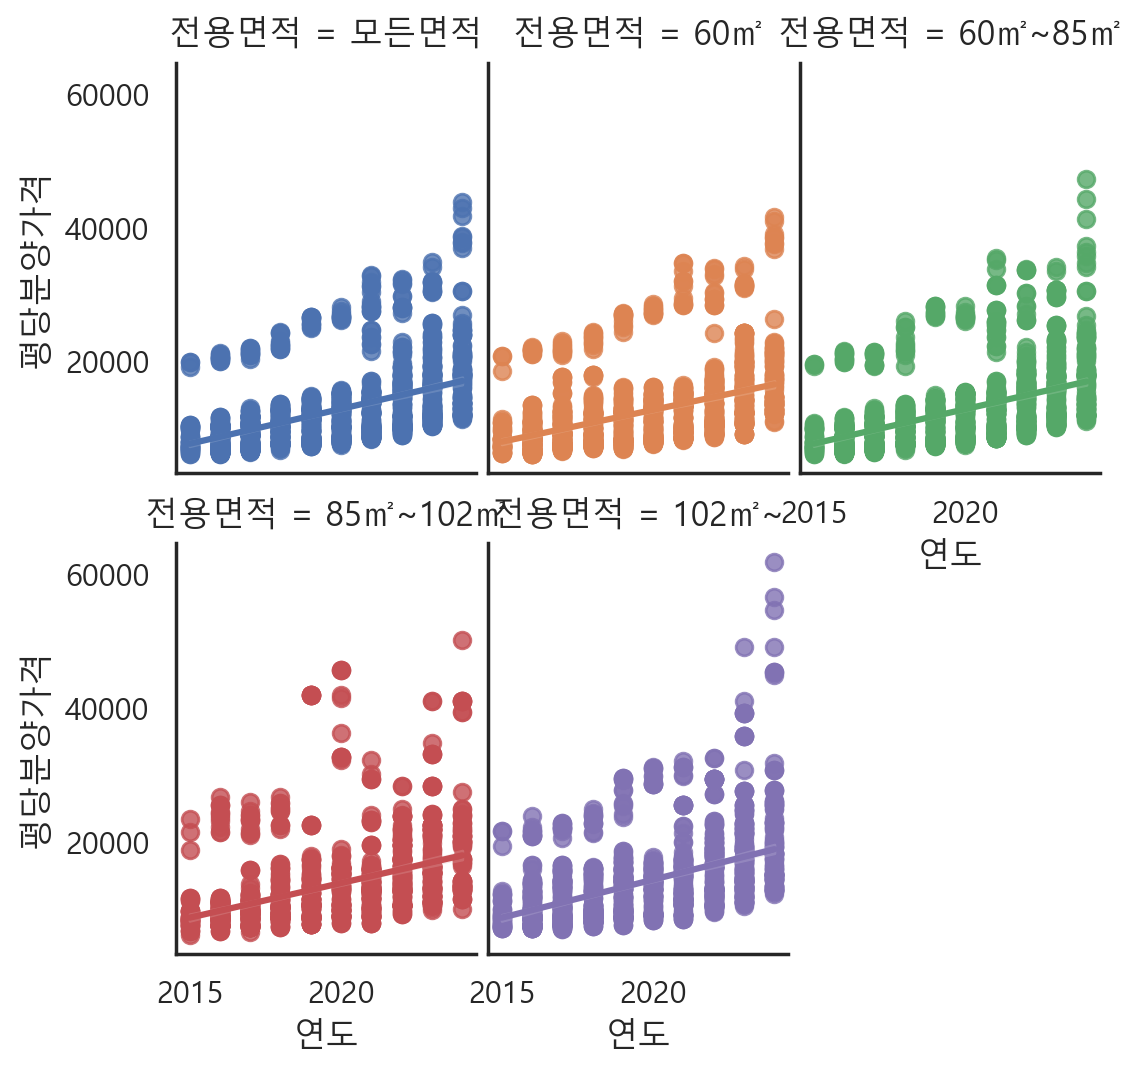

CPU times: total: 6.48 s
Wall time: 2.79 s


In [14]:
%%time
g=sns.lmplot(data=df_last, x = '연도', y = '평당분양가격', hue='전용면적', col='전용면적', col_wrap=3)
g.fig.set_size_inches(5,5)
plt.show()

C:\Users\Admin\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 47.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Admin\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 77.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Admin\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 73.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Admin\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 71.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Admin\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 69.1% of the points

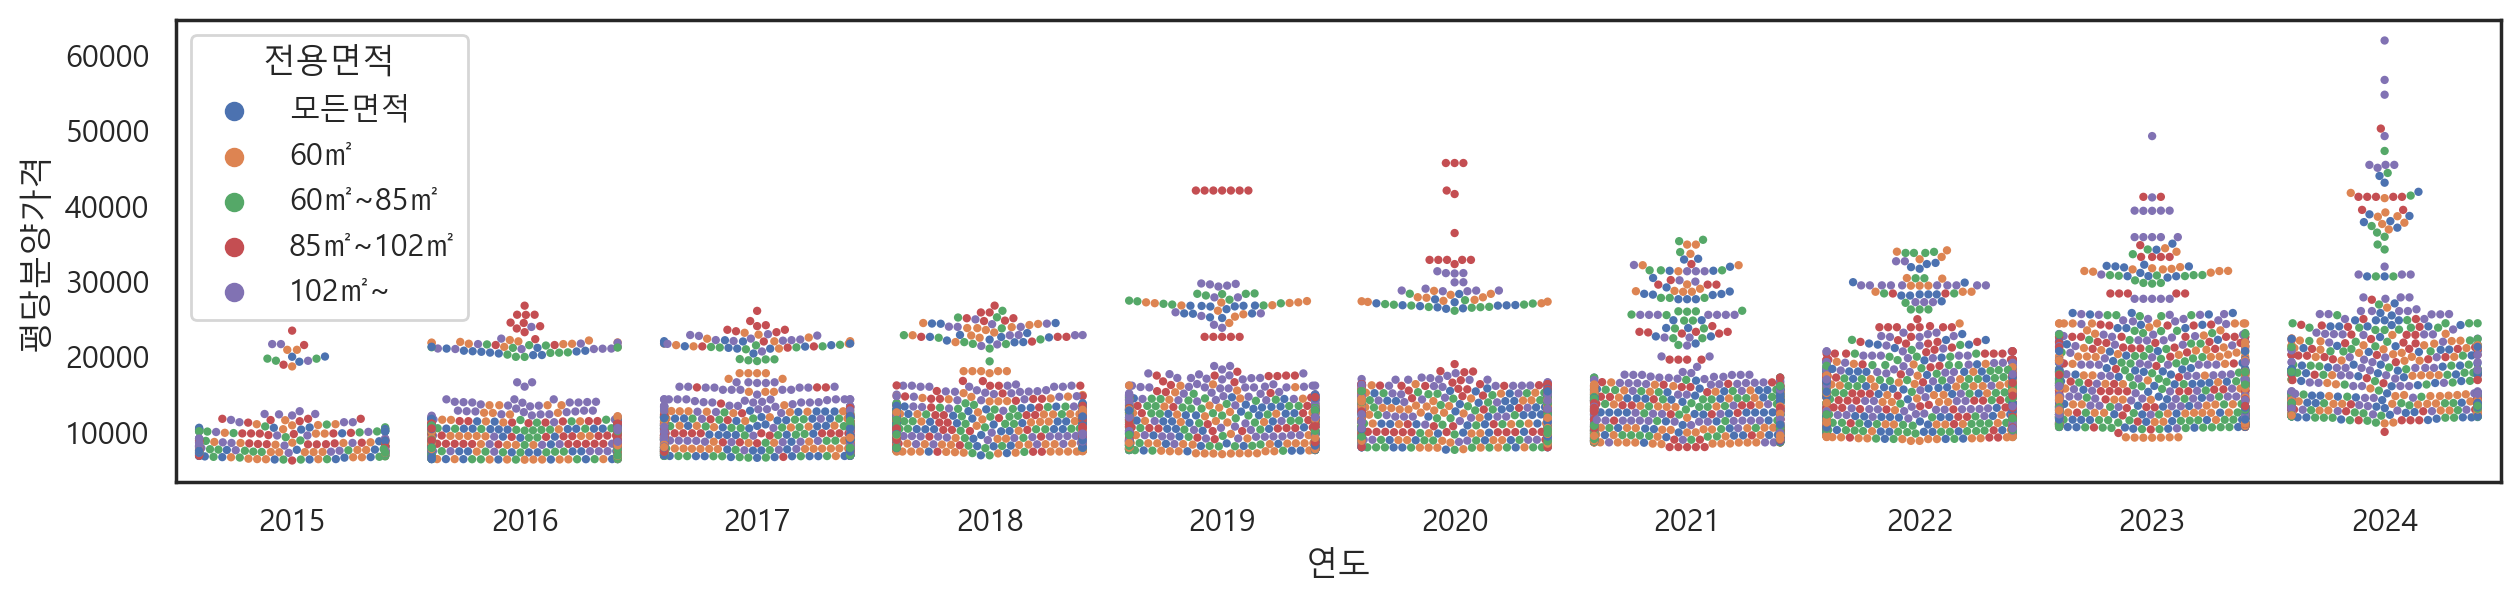

CPU times: total: 1min 49s
Wall time: 1min 53s


In [19]:
%%time
# 분포를 나타내는 swarmplot 많은 데이터 -> 샘플링
df_smaple = df_last.sample(frac=0.1, random_state=12)
sns.swarmplot(data=df_last, x='연도', y='평당분양가격', hue='전용면적', size=3)
plt.show()

In [25]:
%%time
# 분포를 나타내는 swarmplot 많은 데이터 -> 층화샘플링
from sklearn.model_selection import train_test_split_, df_smaple = train_test_split(df_last,
                                                                                    test_size=0.1,
                                                                                    stratify=df_last.연도)


SyntaxError: invalid syntax (<unknown>, line 2)

In [ ]:
sns.swarmplot(data=df_sample, x='연도', y='평당분양가격', hue='전용면적', size=3)

<Axes: >

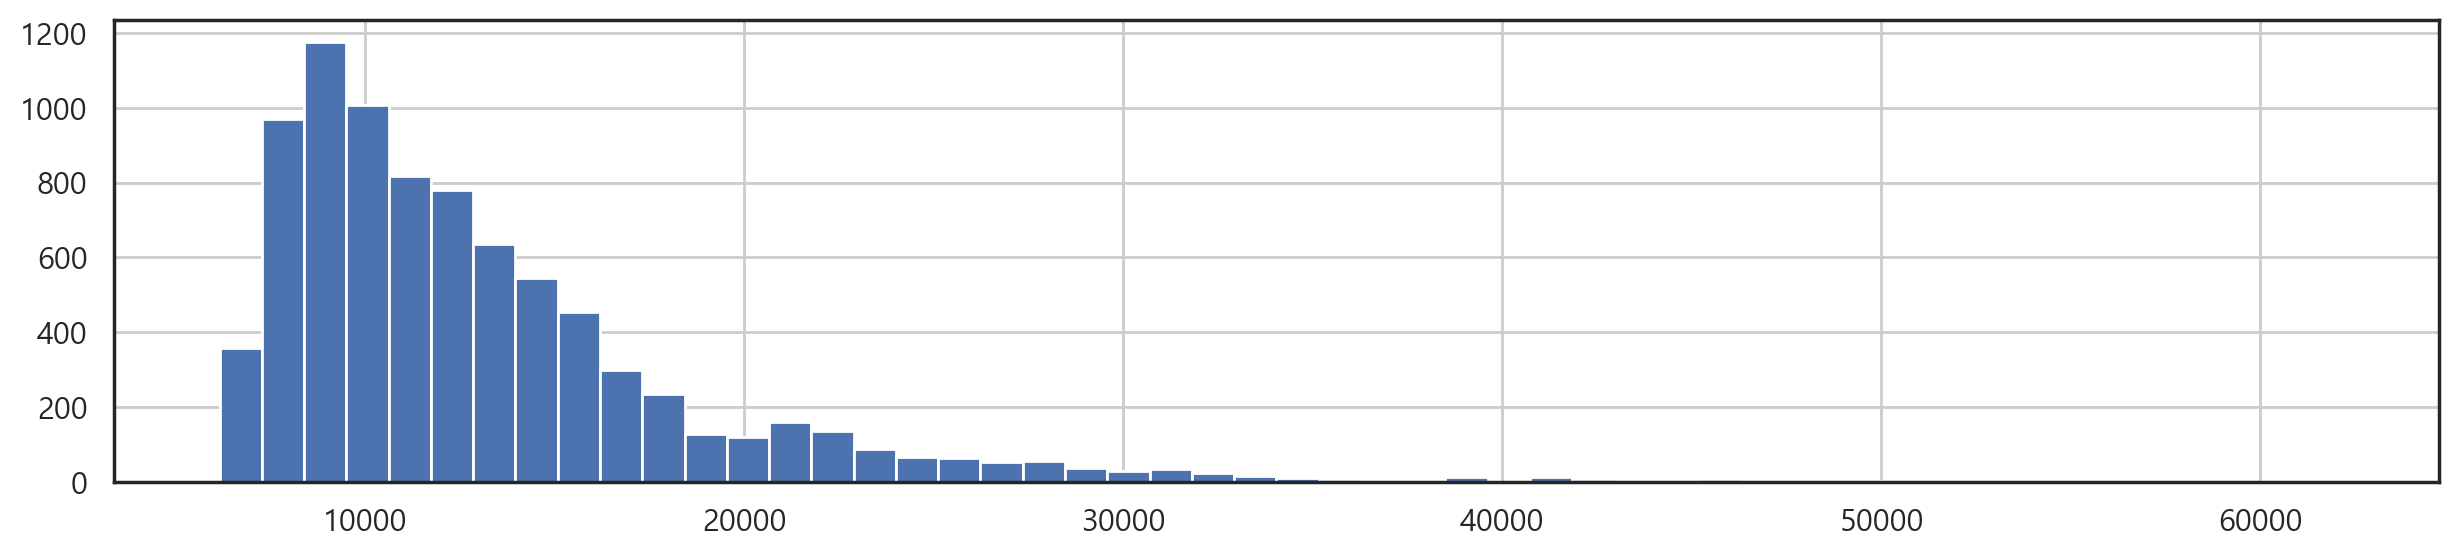

In [37]:
df_last['평당분양가격'].hist(bins=50)

<Axes: xlabel='평당분양가격', ylabel='Count'>

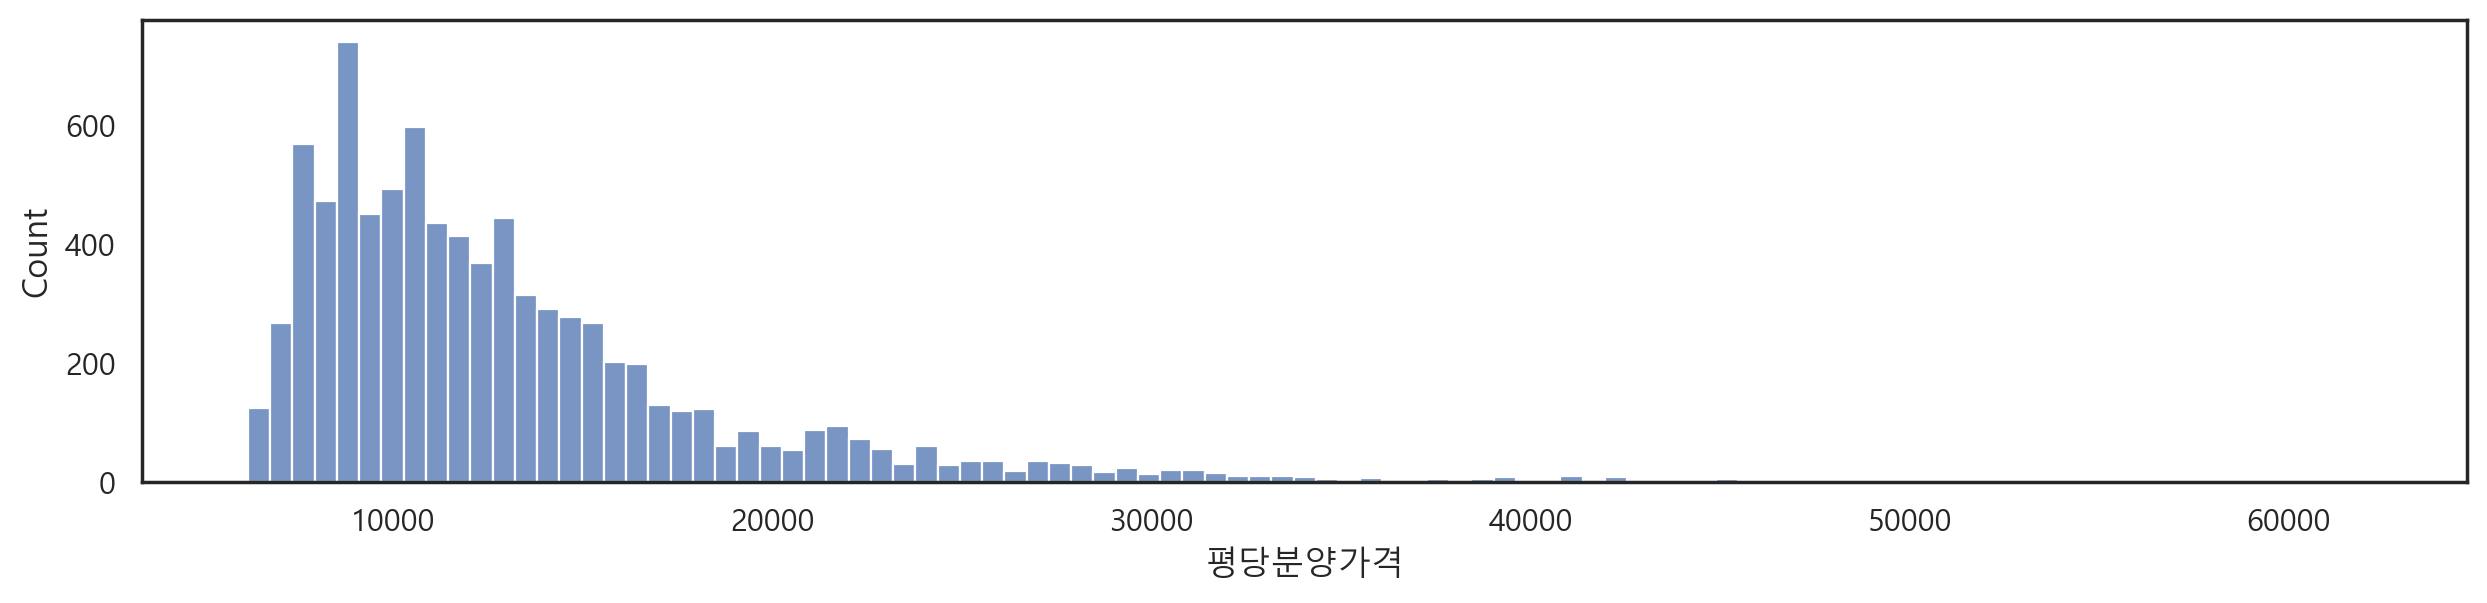

In [28]:
sns.histplot(data=df_last, x='평당분양가격')

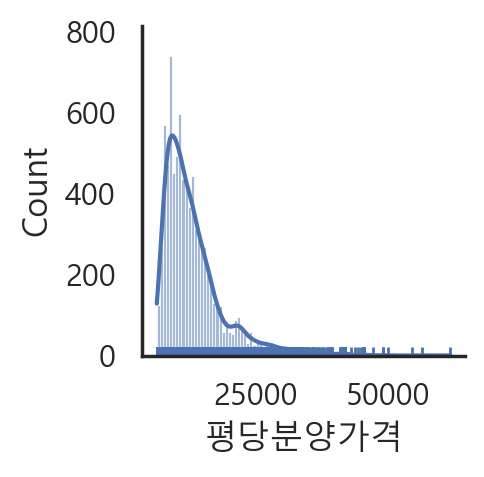

In [35]:
g = sns.displot(data=df_last, x='평당분양가격', kde=True, rug=True)
g.fig.set_size_inches(2,2)

https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot : 범례사용(교안 20page)

# 10. 구조가 다른 df_first와 df_last를 연결 후 분석
## (1) concat
- new_first :df_first를 [지역명, 연도, 월, 평당분양가격]으로 변환
- new_last : df_last를 [지역명, 연도, 월, 평당분양가격]으로 변환
                (전용면적이 모든면적인 행만 추출후, 전용면적 열을 삭제)

In [38]:
df_last

,연도,월,지역명,평당분양가격,전용면적
0,2015,10,서울,19275.3,모든면적
1,2015,10,서울,18651.6,60㎡
2,2015,10,서울,19410.6,60㎡~85㎡
3,2015,10,서울,18879.3,85㎡~102㎡
4,2015,10,서울,19400.7,102㎡~
...,...,...,...,...,...
9090,2024,8,제주,25419.9,모든면적
9091,2024,8,제주,NaN,60㎡
9092,2024,8,제주,24799.5,60㎡~85㎡
9093,2024,8,제주,NaN,85㎡~102㎡


In [66]:
# 문제 5
df_first = pd.read_csv('C:\Ai_x\download\부동산\전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',
                      encoding='cp949')

new_first = df_first.melt(id_vars='지역',
             var_name = '연도월',
             value_name='평당분양가격')
new_first['연도'] = new_first['연도월'].map(lambda data : int(data.split('년')[0]))
new_first['월']=new_first['연도월'].apply(lambda data : int(data.split('년')[1][:-1]))

new_first.drop('연도월', axis=1, inplace=True)
new_first.columns=['지역명','평당분양가격','연도','월']
new_first

<>:2: DeprecationWarning: invalid escape sequence '\A'
<>:2: DeprecationWarning: invalid escape sequence '\A'
C:\Users\Admin\AppData\Local\Temp\ipykernel_2992\2348499543.py:2: DeprecationWarning: invalid escape sequence '\A'
  df_first = pd.read_csv('C:\Ai_x\download\부동산\전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',


,지역명,평당분양가격,연도,월
0,서울,18189,2013,12
1,부산,8111,2013,12
2,대구,8080,2013,12
3,인천,10204,2013,12
4,광주,6098,2013,12
...,...,...,...,...
352,전북,6580,2015,8
353,전남,6289,2015,8
354,경북,7037,2015,8
355,경남,7665,2015,8


In [92]:
df_first = pd.read_csv('C:\Ai_x\download\부동산\전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',
                      encoding='cp949')
df_first.sample()

new_first['연도월'].str.split('년')[0]



,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
12,전북,6282,6281,5946,5966,6277,6306,6351,6319,6436,...,6583,6583,6583,6583,6542,6551,6556,6601,6750,6580


In [93]:
new_first = df_first.melt(id_vars='지역',
             var_name = '연도월',
             value_name='평당분양가격')
new_first.head()

,지역,연도월,평당분양가격
0,서울,2013년12월,18189
1,부산,2013년12월,8111
2,대구,2013년12월,8080
3,인천,2013년12월,10204
4,광주,2013년12월,6098


In [94]:
new_first['연도월'].str.split('년')[0]

['2013', '12월']

In [95]:
# 연도 return
def parse_year(data):
    return int(data.split('년')[0])
parse_year("2013년 12월")

2013

In [96]:
# 월 return
def parse_month(data):
    return (data.split('년')[1][:-1])
parse_month("2013년 12월")

' 12'

In [98]:
new_first['연도'] = new_first['연도월'].map(lambda data : int(data.split('년')[0]))
new_first.head(1)

,지역,연도월,평당분양가격,연도
0,서울,2013년12월,18189,2013


In [99]:
new_first['월']=new_first['연도월'].apply(lambda data : int(data.split('년')[1][:-1]))
new_first.head(1)

,지역,연도월,평당분양가격,연도,월
0,서울,2013년12월,18189,2013,12


In [100]:
new_first['월']=new_first['연도월'].apply(lambda data : int(data.split('년')[1][:-1]))
new_first.head(1)

,지역,연도월,평당분양가격,연도,월
0,서울,2013년12월,18189,2013,12


In [101]:
new_first.drop('연도월', axis=1, inplace=True)

In [102]:
new_first.columns=['지역명','평당분양가격','연도','월']

In [109]:
new_last = df_last[df_last.전용면적 == '모든면적'].copy()
new_last.drop('전용면적', axis=1, inplace=True)

In [123]:
print(new_first.columns)
print(new_first.columns)

Index(['지역명', '평당분양가격', '연도', '월'], dtype='object')
Index(['지역명', '평당분양가격', '연도', '월'], dtype='object')


In [146]:
df = pd.concat([new_first, new_last],axis=0)
df

,지역명,평당분양가격,연도,월
0,서울,18189.0,2013,12
1,부산,8111.0,2013,12
2,대구,8080.0,2013,12
3,인천,10204.0,2013,12
4,광주,6098.0,2013,12
...,...,...,...,...
9070,전북,12058.2,2024,8
9075,전남,13120.8,2024,8
9080,경북,13827.0,2024,8
9085,경남,13252.8,2024,8


In [147]:
df.reset_index(drop=True, inplace = True)

In [148]:
df.index

RangeIndex(start=0, stop=2176, step=1)

In [142]:
df = df[['지역명', '연도', '월', '평당분양가격']]
df.head()

,지역명,연도,월,평당분양가격
0,서울,2013,12,18189.0
1,부산,2013,12,8111.0
2,대구,2013,12,8080.0
3,인천,2013,12,10204.0
4,광주,2013,12,6098.0


## (2) 결측치 대체(연도별, 지역별 중위값)

In [159]:
df.isna().sum()

지역명        0
평당분양가격    26
연도         0
월          0
dtype: int64

In [160]:
df[df['평당분양가격'].isna()].head(1)

,지역명,평당분양가격,연도,월
1010,울산,NaN,2018,12


In [161]:
# 연도별 지역별 중앙값으로 결측치 대처 방법 1
fillnavalue = df.groupby(['연도','지역명'])['평당분양가격'].median().unstack()
fillnavalue = df.pivot_table(index='연도',
                             columns='지역명',
                             values='평당분양가격',
                             aggfunc='median')
fillnavalue

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
연도,,,,,,,,,,,,,,,,,
2013,6230.00,10855.00,6473.00,6168.00,6098.00,8080.00,8321.00,8111.00,18189.00,7601.0,8090.00,10204.00,5678.00,6282.00,7674.00,6365.00,6589.00
2014,6350.00,10449.00,6611.50,6555.00,7617.00,8317.00,8327.00,9233.00,19070.50,8067.0,8153.00,10018.00,5716.00,6335.00,7900.00,6724.50,6593.50
2015,6986.00,10518.00,7665.00,7006.00,7914.00,8542.00,8079.00,9515.00,19275.30,8669.0,9192.00,10443.00,6243.00,6583.00,7365.60,6975.00,6705.60
2016,6964.65,11342.10,7865.55,7385.40,8987.55,10335.60,8380.35,10414.80,20654.70,8860.5,10127.70,10531.95,6491.10,6369.00,9329.10,7377.15,6801.30
2017,7057.05,11919.60,8052.00,7835.85,9551.85,11231.55,9035.40,11851.95,21402.15,9018.9,11488.95,10875.15,7114.80,7222.05,10885.05,7448.10,6765.00
2018,7669.20,13099.35,8898.45,8667.45,9678.90,12178.65,9807.60,12926.10,22567.05,10388.4,10312.50,11233.20,7774.80,7652.70,11649.00,8030.55,7870.50
2019,8221.95,14487.00,9791.10,8723.55,12071.40,13963.95,11866.80,13061.40,26428.05,11411.4,10362.00,12827.10,7920.00,8146.05,12561.45,8598.15,7570.20
2020,9271.35,14331.90,10263.00,9929.70,12624.15,15302.10,11030.25,13266.00,26769.60,11355.3,12581.25,14648.70,8571.75,8225.25,15130.50,8863.80,7924.95
2021,9607.95,14173.50,10523.70,10338.90,14127.30,15528.15,12196.80,14460.60,29769.30,12533.4,14256.00,14950.65,9857.10,8834.10,23756.70,9306.00,8677.35


In [162]:
def fillna_median(row):
    'row.평당분양가격이 결측치면 fillnavalue[row.연도,row.지역명]으로 대처하고 row return'
    year = row.연도
    loc = row['지역명']
    if np.isnan(row.평당분양가격):
        row['평당분양가격'] = fillnavalue.loc[year, loc]
    return row
fillna_median(df.loc[1010]),fillna_median(df.loc[0])

(지역명            울산
 평당분양가격    10312.5
 연도           2018
 월              12
 Name: 1010, dtype: object,
 지역명            서울
 평당분양가격    18189.0
 연도           2013
 월              12
 Name: 0, dtype: object)

In [168]:
df1 = df.apply(fillna_median, axis=1).isna().sum()
df1.isnull().sum()

0

In [164]:
# 연도별 지역별 중앙값으로 결측치 대처 방법 2
df2 = df.copy()
df2['평당분양가격'] = df2.groupby(['지역명','연도'])['평당분양가격']\
                           .transform(lambda x : x.fillna(x.median()))

In [169]:
df2.isnull().sum()

지역명       0
평당분양가격    0
연도        0
월         0
dtype: int64

In [170]:
df1==df2

,지역명,평당분양가격,연도,월
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
2171,False,False,False,False
2172,False,False,False,False
2173,False,False,False,False
2174,False,False,False,False


## (3) df.csv파일로 출력

In [171]:
df2.to_csv('C:\Ai_x\download\부동산\최종전국평당분양가격(결측치제외).csv', index=False,  encoding='cp949')

## (4) 7절부터 9절까지 분석을 한다(전용면적별 분석은 불가)

- 지역명별 데이터 갯수는 결측치가 없어서 동일(groupby나 pivot_table등으로 확인)
- 지역명별 평당분양가격(groupby, pivot_table, plot, seaborn 연습)
- 연도별 지역명별 평당분양가격(groupby, pivot_table, plot, seaborn 연습)

### ① 지역명별 데이터 행 갯수 : 결과가 1차원 시리즈

In [191]:
df_last['지역명'].value_counts()

서울    535
강원    535
경남    535
경북    535
전남    535
전북    535
충남    535
충북    535
세종    535
인천    535
울산    535
대전    535
광주    535
대구    535
부산    535
경기    535
제주    535
Name: 지역명, dtype: int64

### ② 지역별 평당분양가격(평균, 최대값, ... 요약통계량)

In [188]:
df_last.groupby('지역명')['평당분양가격'].mean().sort_values(ascending=False)

지역명
서울    27755.404554
제주    15912.434624
경기    15420.030280
부산    14896.949156
인천    14513.232203
대구    14434.520000
울산    13958.197975
광주    12998.216000
대전    12829.565060
경남    10776.955814
세종    10741.830807
경북    10261.553425
강원    10078.717400
충남     9769.541279
전남     9224.326627
충북     8896.583302
전북     8886.201923
Name: 평당분양가격, dtype: float64

In [189]:
df_last.pivot_table(index='지역명',
                   values='평당분양가격',
                   aggfunc='mean')


,평당분양가격
지역명,
강원,10078.717400
경기,15420.030280
경남,10776.955814
경북,10261.553425
광주,12998.216000
대구,14434.520000
대전,12829.565060
부산,14896.949156
서울,27755.404554


In [190]:
df_last.pivot_table(index='지역명',
                   values='평당분양가격',
                   aggfunc='max')


,평당분양가격
지역명,
강원,17806.8
경기,24172.5
경남,16566.0
경북,15345.0
광주,24951.3
대구,30600.9
대전,30851.7
부산,31904.4
서울,61917.9


<Axes: xlabel='지역명'>

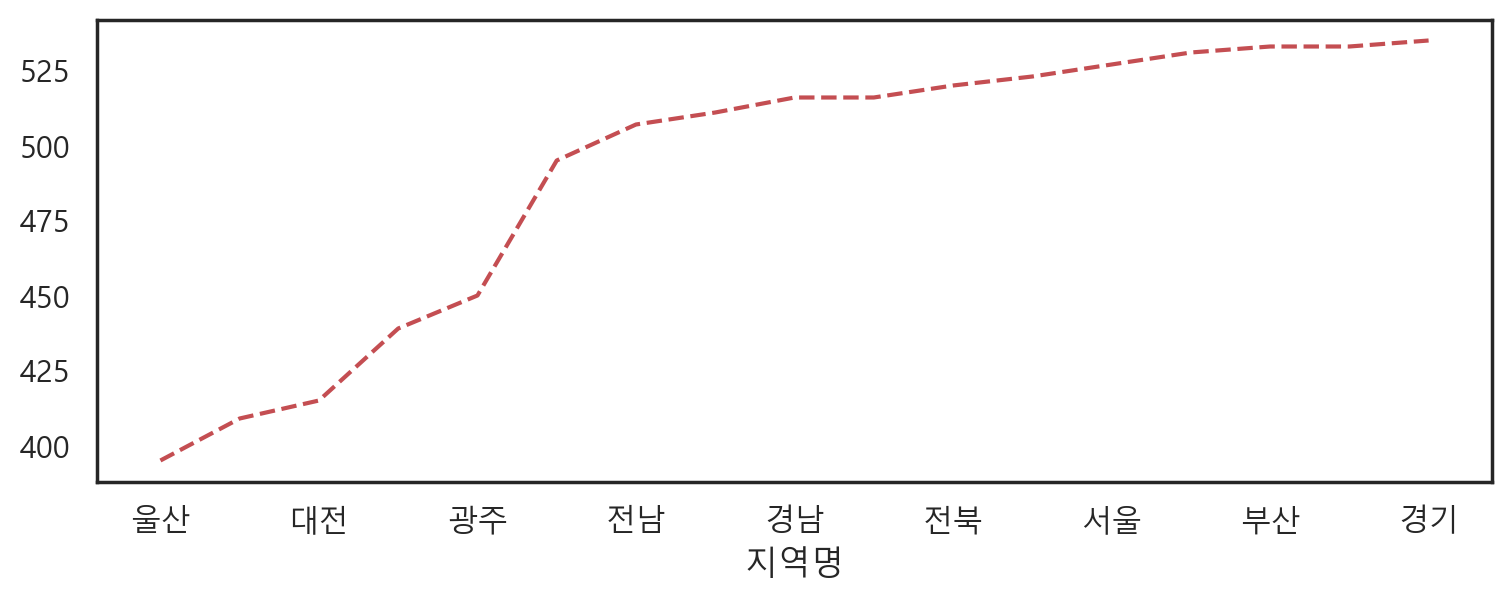

In [192]:
# 지역명당 평당분양가격 시각화(lineplot과 matplotlib의 bar, sns의 barplot)
result = df_last.groupby('지역명')['평당분양가격'].count().sort_values()
plt.figure(figsize=(9,3))
result.plot(kind='line', color = 'r', linestyle='--')


<Axes: xlabel='지역명'>

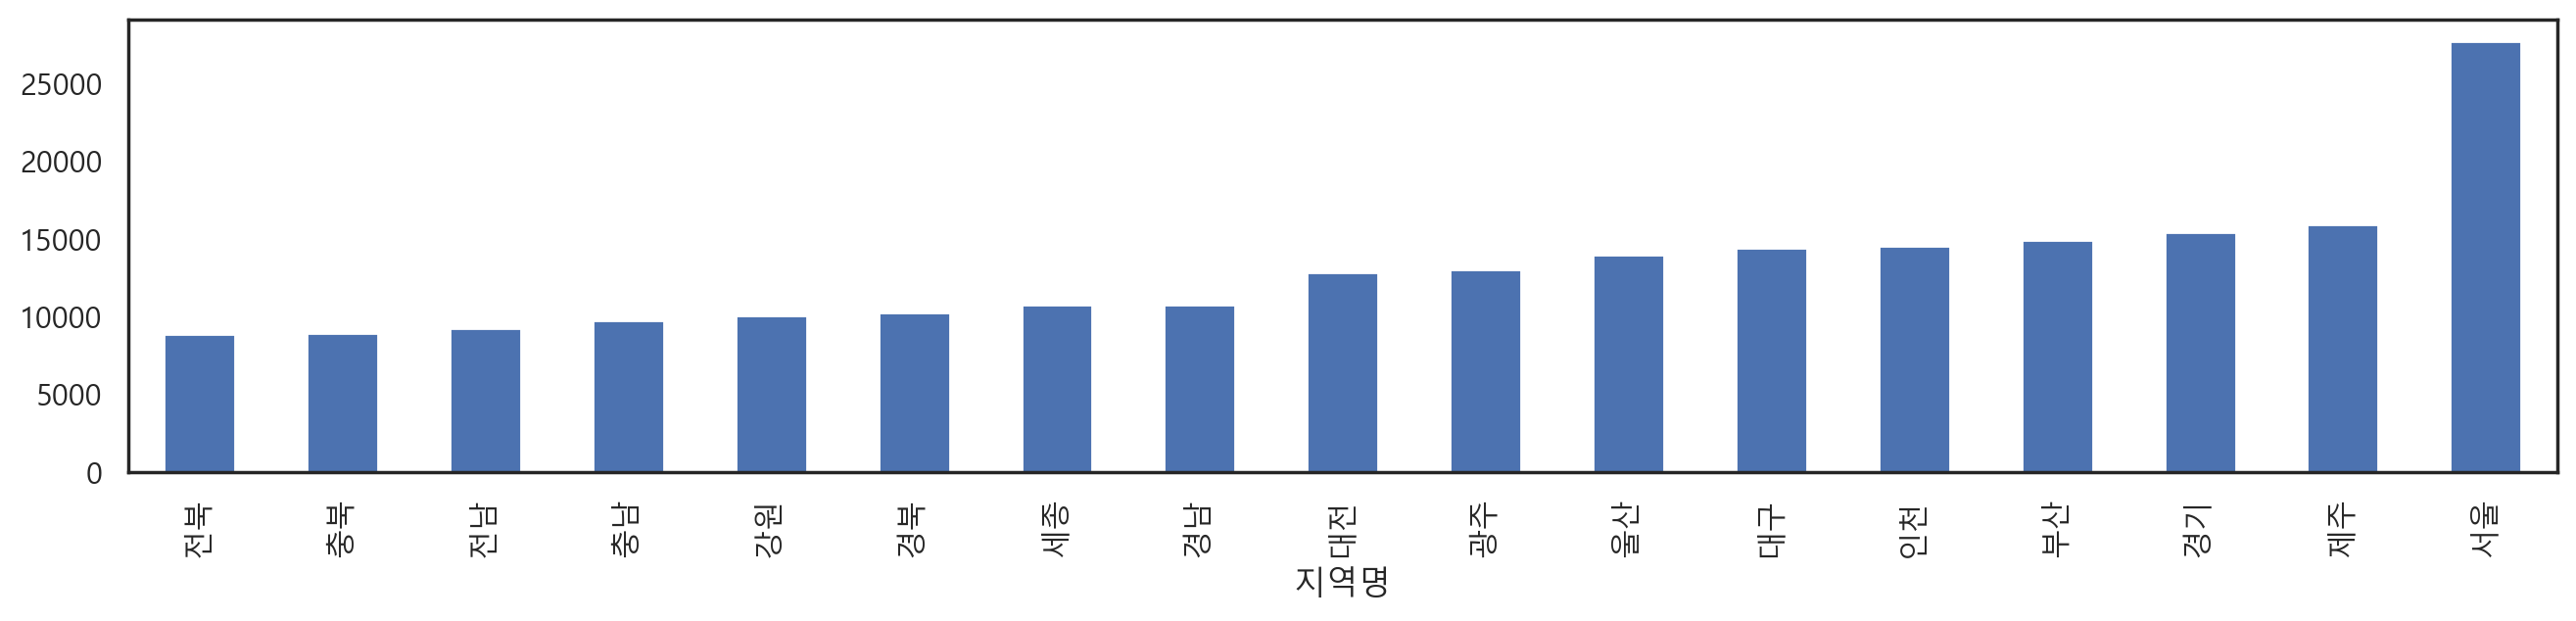

In [193]:
df_last.groupby('지역명')['평당분양가격'].mean().sort_values().plot(kind='bar', figsize=(16,3))

### ③ 연도별 평당분양가격(평균)

In [195]:
df_last.groupby('연도')['평당분양가격'].mean().sort_values(ascending=False)

연도
2024    18962.919231
2023    16890.920657
2022    14942.504494
2021    13636.022540
2020    13039.422449
2019    12188.293092
2018    10978.938411
2017    10372.928923
2016     9683.025000
2015     9202.735802
Name: 평당분양가격, dtype: float64

In [197]:
for year, val in zip(result.index, result):
    print(year, val)

울산 395
세종 409
대전 415
제주 439
광주 450
대구 495
전남 507
경북 511
경남 516
충남 516
전북 520
강원 523
서울 527
인천 531
부산 533
충북 533
경기 535


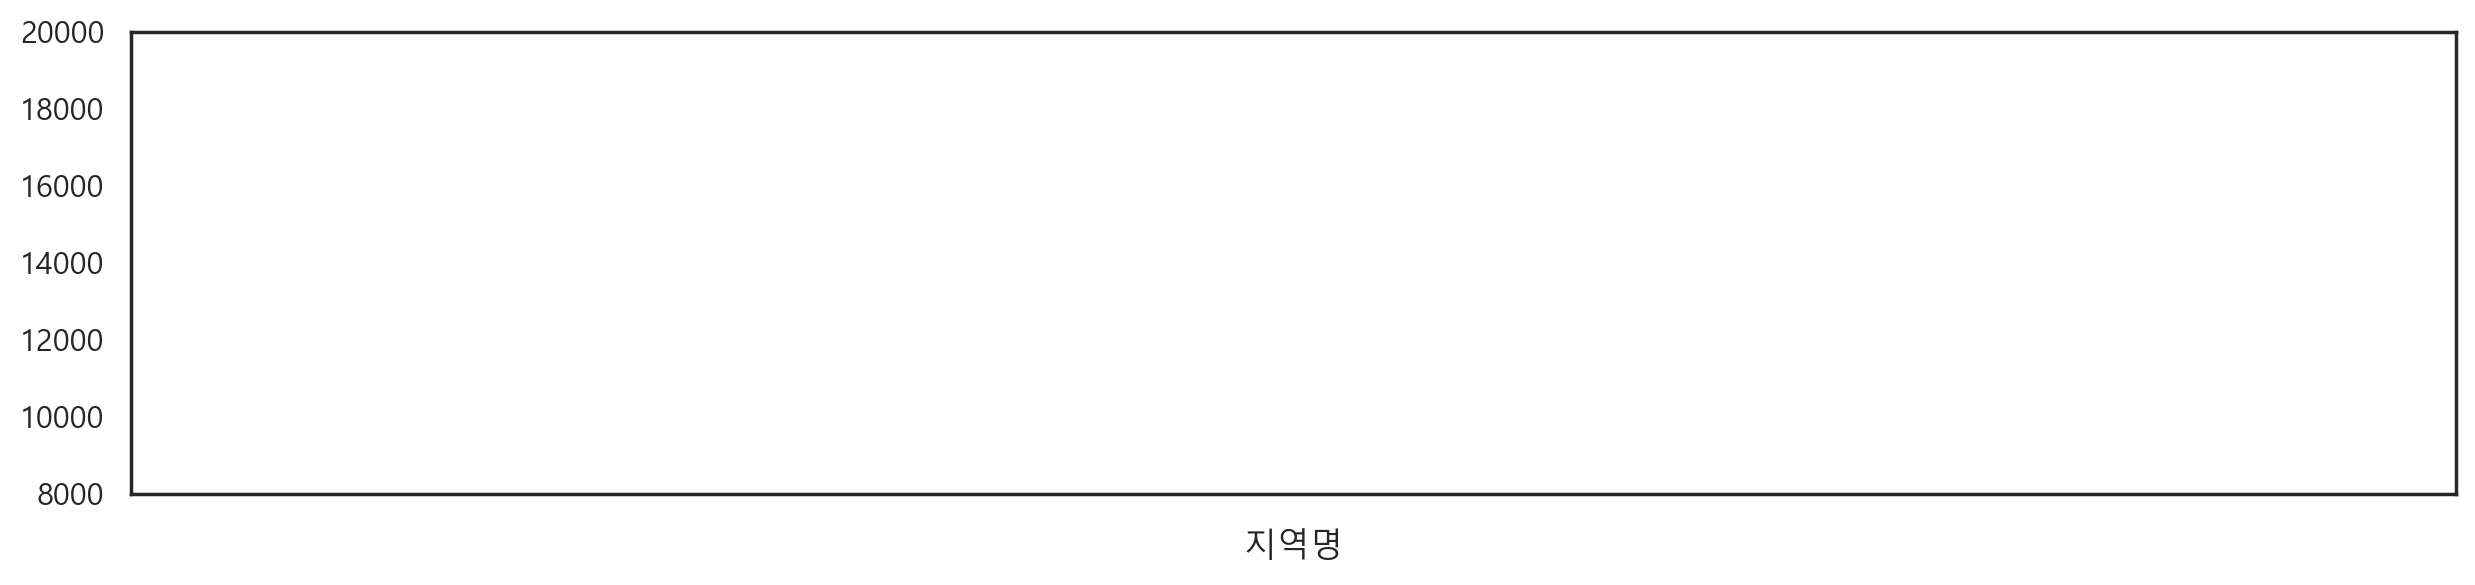

In [199]:
result.plot(kind='line',figsize=(15,3))
plt.ylim([8000,20000])
plt.xticks(range(2015,2025))

plt.show()

### ④ 연도, 지역별 평당분양가격(평균)

In [ ]:
# 연도별, 지역별 평당분양가격 시각화(heatmap)

In [ ]:
# 년도별 평균 평당분양가격의 추이

In [ ]:
# 위의 그래프가 겹쳐서 작 보이지 않아 분리

In [ ]:
# 관계형 그래프의 서브플롯을 그리는 함수는 relplot
# 범주형 그래프의 서브플롯을 그리는 함수는 catplot

In [ ]:
# 연도별 평당분양가격의 사분위수


In [ ]:
# 연도별 평당분양가격의 사분위수(분포포함 boxenplot)


In [ ]:
# 연도별 평당분양가격의 사분위수(분포포함 violinplot)


In [ ]:
# 연도에 따른 평당분양가격을 회귀식으로 시각화


In [ ]:
# swarmplot은 많은 데이터를 그리기에는 시간이 많이 걸려 5%만 sampling후 그릴 것을 추천
# 연도별 평당분양가격 산점도
 

In [ ]:
# 분양가격을 hist
